## PISTE 2 - Classification des comportements

Apprentissage non supervisé => GMM

#### 0. Initialisation:

In [1]:
#install.packages("corrplot")

In [2]:
library("caret")
library("cluster")
library("corrplot")
library("corrr")
library("CVglasso")
library("e1071")
library("fda")
library("ggplot2")
library("glasso")
library("igraph")
library("mclust")
library("nnet")
library("pls")
library("qgraph")
library("randomForest")
library("readr")
library("splines")
library("tibble")
library("tidymodels")
library("VGAM")
library("xgboost")

Le chargement a nécessité le package : ggplot2

Le chargement a nécessité le package : lattice

corrplot 0.95 loaded


Attachement du package : ‘e1071’


L'objet suivant est masqué depuis ‘package:ggplot2’:

    element


Le chargement a nécessité le package : splines

Le chargement a nécessité le package : fds

Le chargement a nécessité le package : rainbow

Le chargement a nécessité le package : MASS

Le chargement a nécessité le package : pcaPP

Le chargement a nécessité le package : RCurl

Le chargement a nécessité le package : deSolve


Attachement du package : ‘fda’


L'objet suivant est masqué depuis ‘package:lattice’:

    melanoma


L'objet suivant est masqué depuis ‘package:graphics’:

    matplot


L'objet suivant est masqué depuis ‘package:datasets’:

    gait



Attachement du package : ‘igraph’


Les objets suivants sont masqués depuis ‘package:stats’:

    decompose, spectrum


L'objet suivant est masqué depuis ‘package:base’:

    union


Package 'mclust' version 6.1.2


#### 1. Importation données:

In [3]:
behaviour <- read.csv('../../piste_2/data/multispec_bsplines_median_agreg2_IGT.csv', row.names = 'X')
head(behaviour)

,bspline_1_1,bspline_2_1,bspline_3_1,bspline_4_1,bspline_5_1,bspline_6_1,bspline_7_1,bspline_8_1,bspline_9_1,bspline_1_2,⋯,bspline_9_2,bspline_1_3,bspline_2_3,bspline_3_3,bspline_4_3,bspline_5_3,bspline_6_3,bspline_7_3,bspline_8_3,bspline_9_3
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1-2Dichloroethane,0.0428599502,0.3104169809,0.5140330488,0.269480113,0.0432431615,0.1191663208,-0.161778078,0.02312422,-0.3382460723,0.3191718511,⋯,0.046915940,0.150049446,-0.23951635,0.327802521,-0.311698492,-0.767715644,-0.78753003,-0.68081242,-0.77054578,-0.611039982
1-chlorodecane,-0.0012663269,0.0212297344,-0.0143353314,0.035529260,0.0156677416,0.0116948309,0.060606854,0.07095725,0.0206552934,0.0071250680,⋯,0.022286039,0.000000000,0.00000000,0.000000000,0.000000000,0.000000000,0.00000000,0.00000000,0.00000000,0.000000000
124-Trichlorobenzene,0.0115107927,0.0128482665,0.0275044208,0.015711864,0.0280358371,-0.0105425596,0.011499964,0.01142211,0.0028426074,-0.0146936592,⋯,0.004155809,0.084781740,0.01356785,-0.006526794,0.006867849,0.007203797,-0.03415222,0.13256952,0.02025038,0.100817682
4-octylphenol,0.1919322615,-0.2855992927,0.4688403629,-0.461324267,2.3234831092,0.6141764850,1.787215174,-0.47782508,0.9492905666,0.0069378247,⋯,1.463942855,0.066319541,-0.11565605,0.181565092,0.119775167,0.269533574,0.45472705,0.75486122,0.74136268,0.656515341
A736,0.0001266427,-0.0002040018,0.0002881707,0.001465421,0.0005435396,-0.0005483989,0.001493525,-0.01689305,0.0002838245,0.0489670559,⋯,0.004387048,-0.001514373,0.00000000,-0.003432376,0.000000000,0.000000000,0.00000000,0.02151884,-0.01236712,0.004480931
Acetone,-0.1037677172,0.2436964285,-0.2286078720,0.459528151,0.2982836627,0.0379303268,0.193872492,-0.03598312,0.0639831126,0.0008141887,⋯,-0.006512883,-0.015854805,0.02576582,-0.037440308,0.043701629,-0.120702916,-0.05173680,-0.04268549,-0.12009924,0.066707120


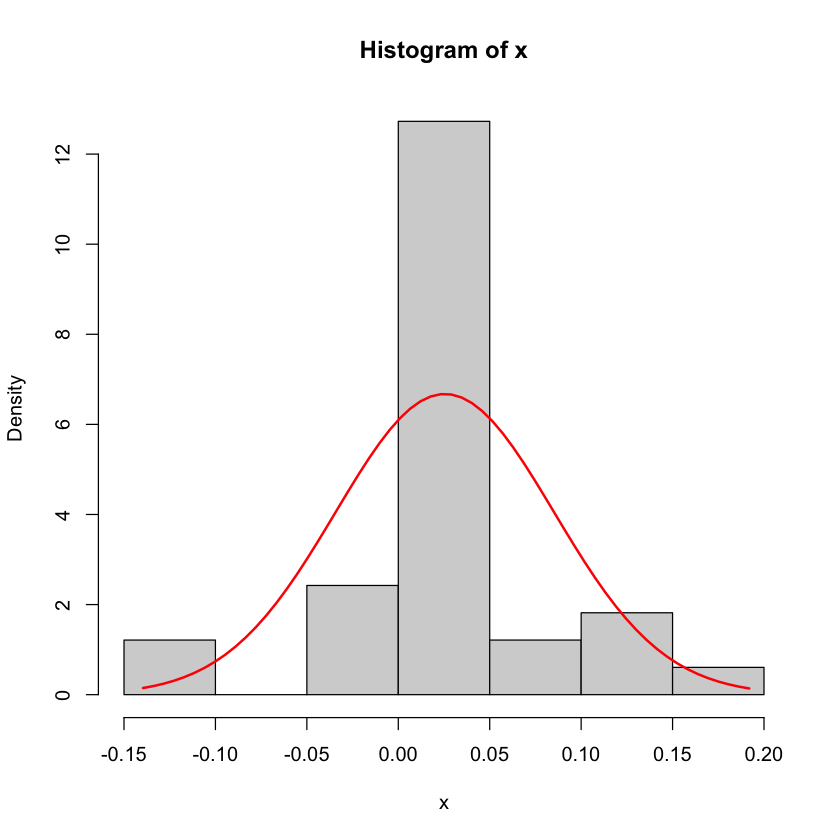

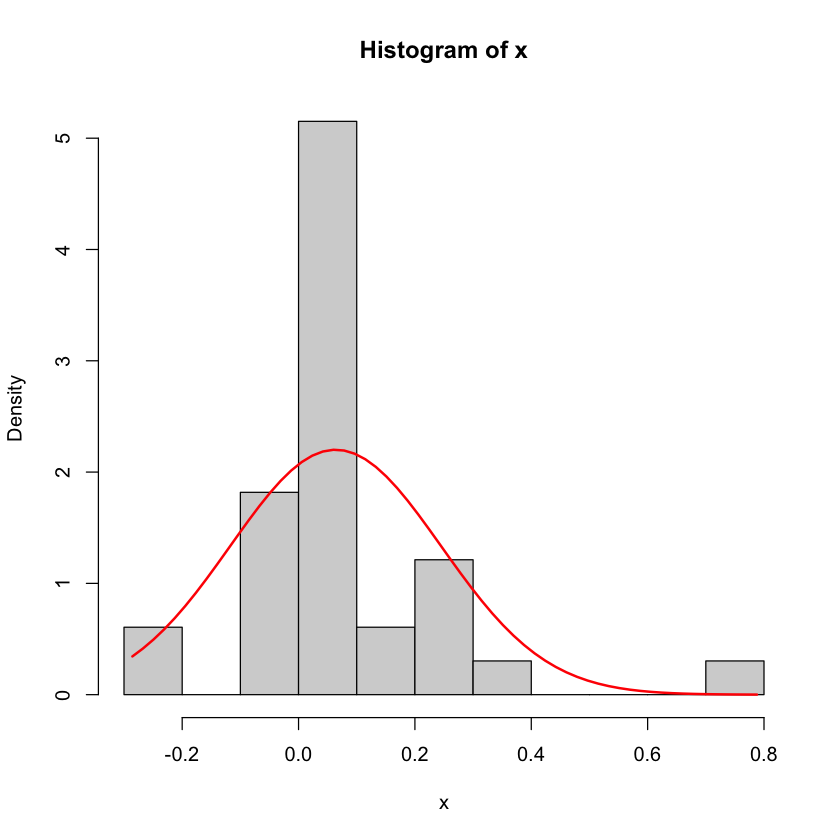

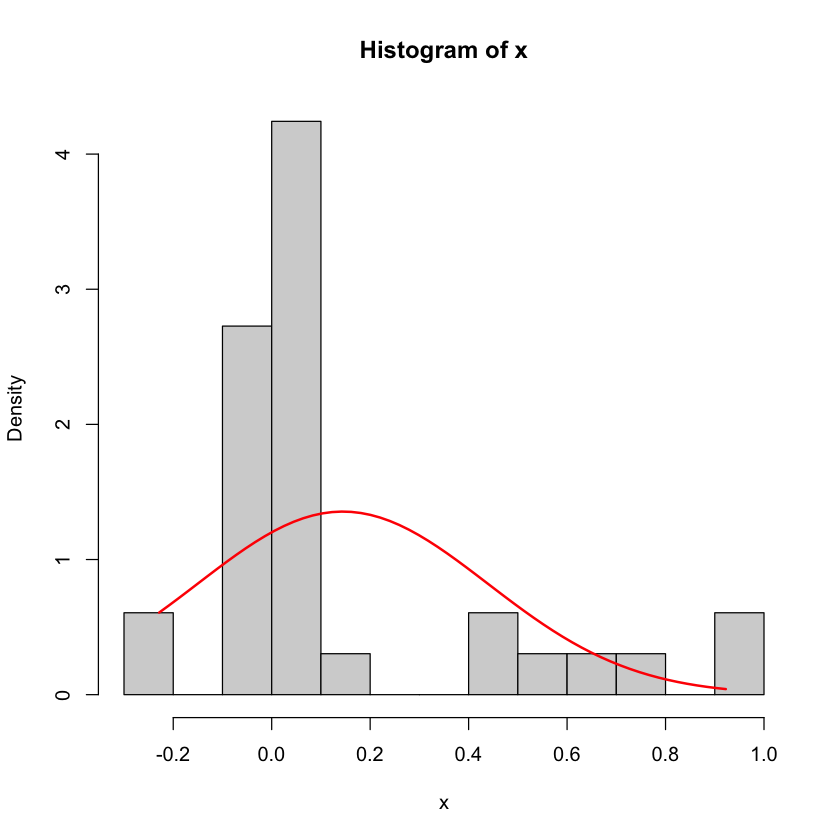

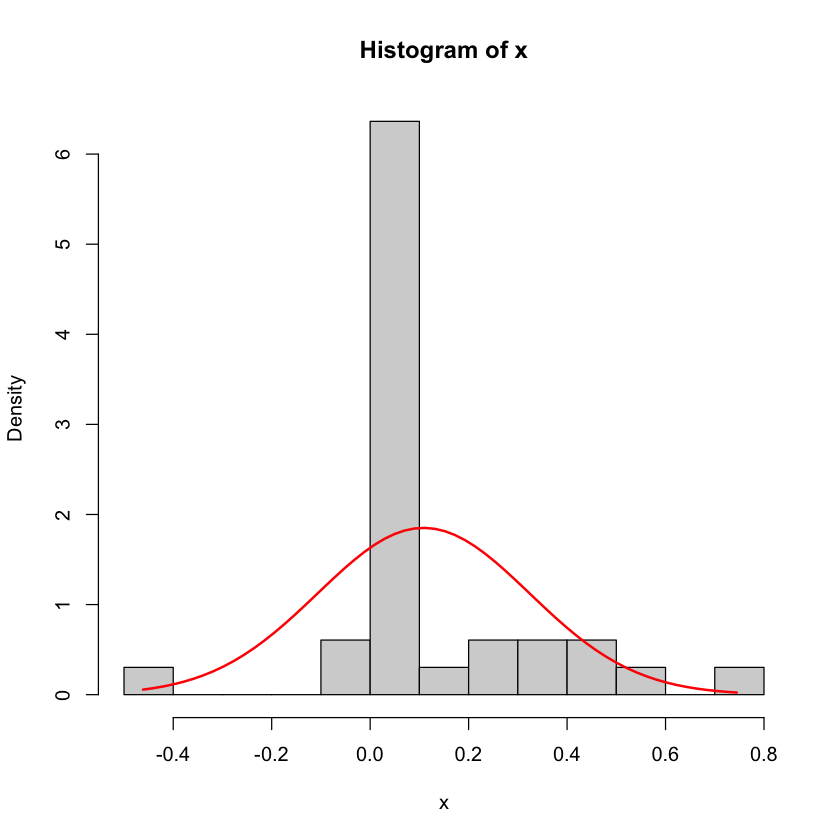

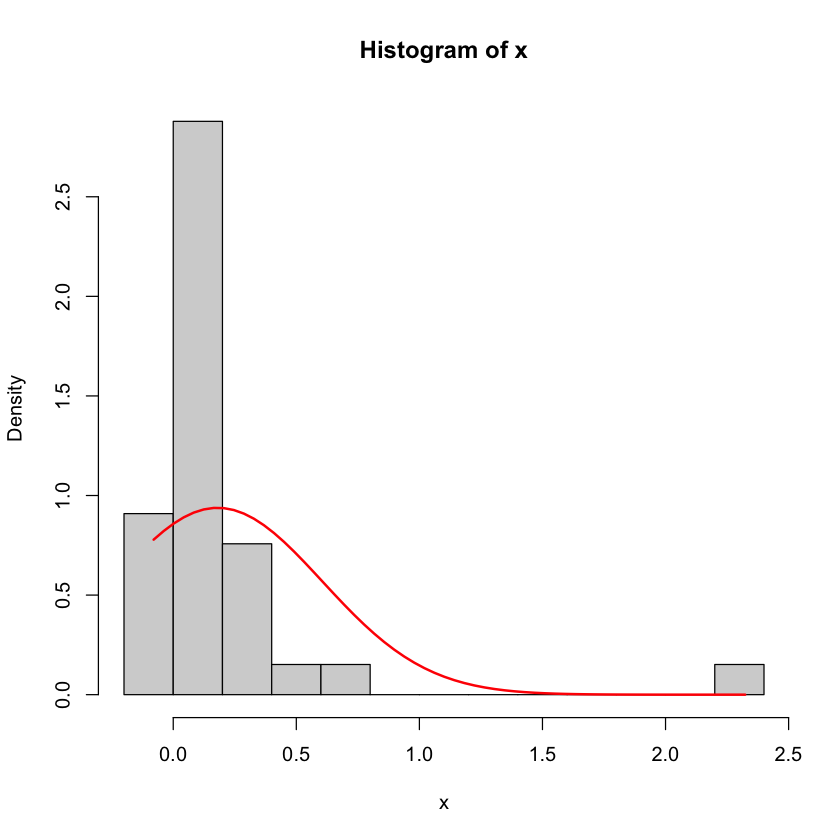

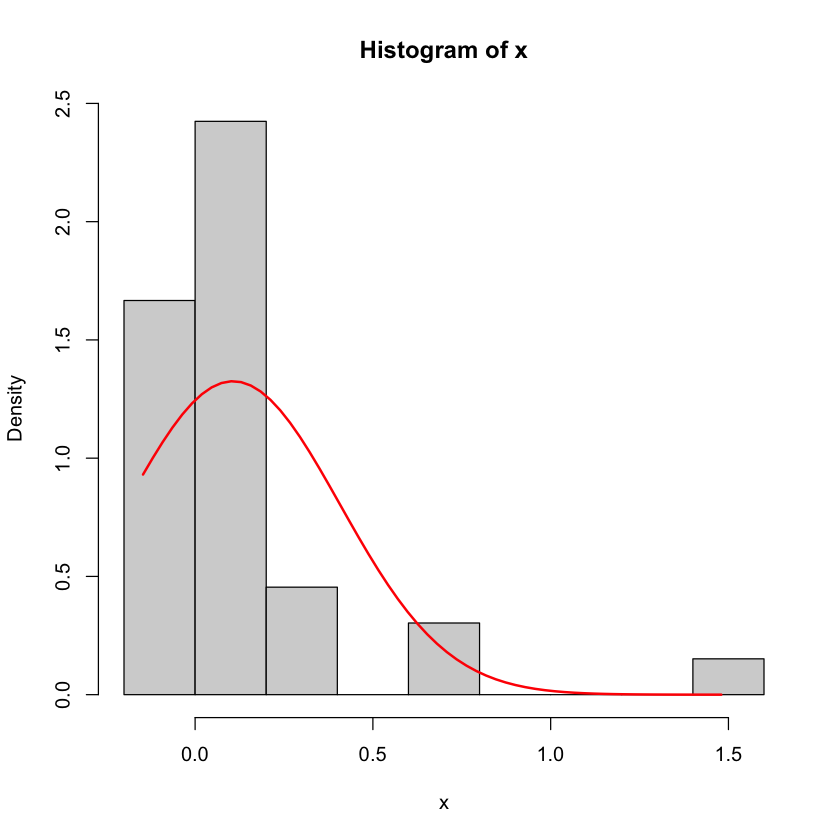

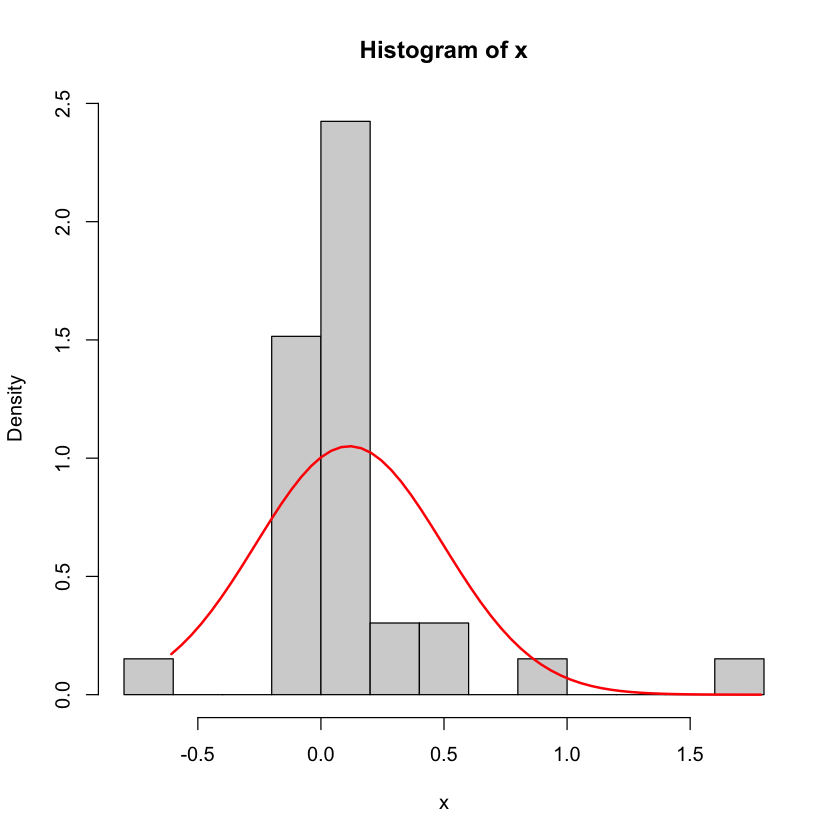

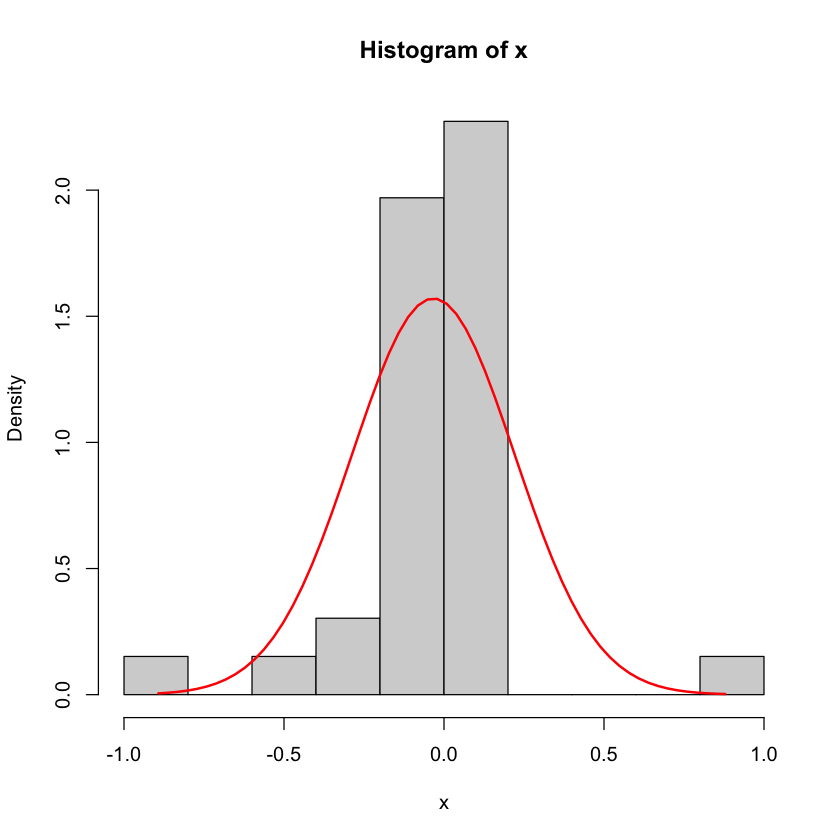

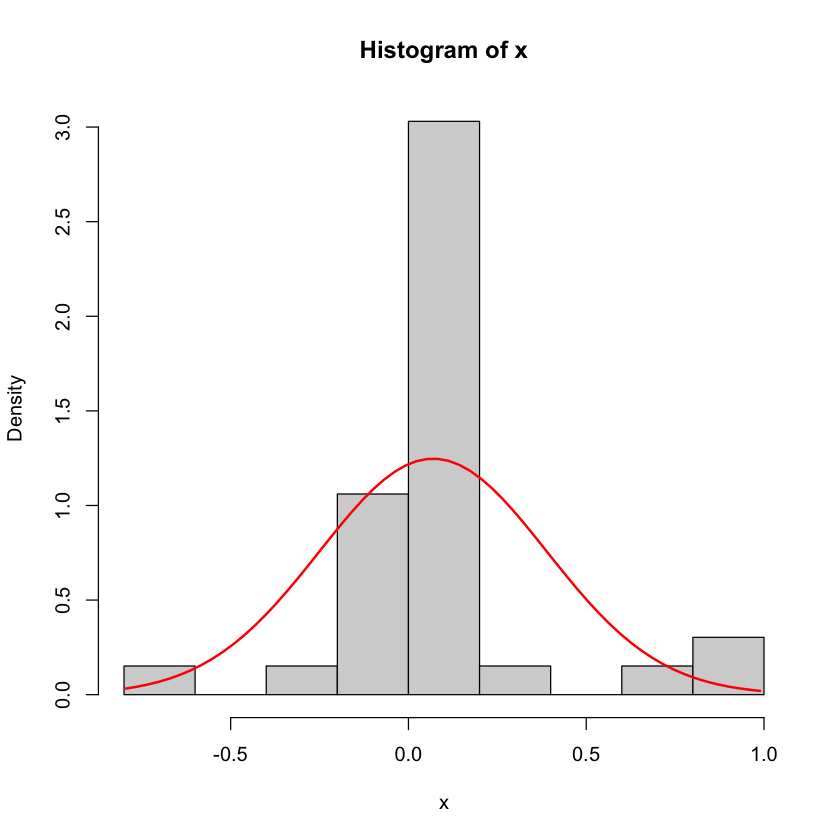

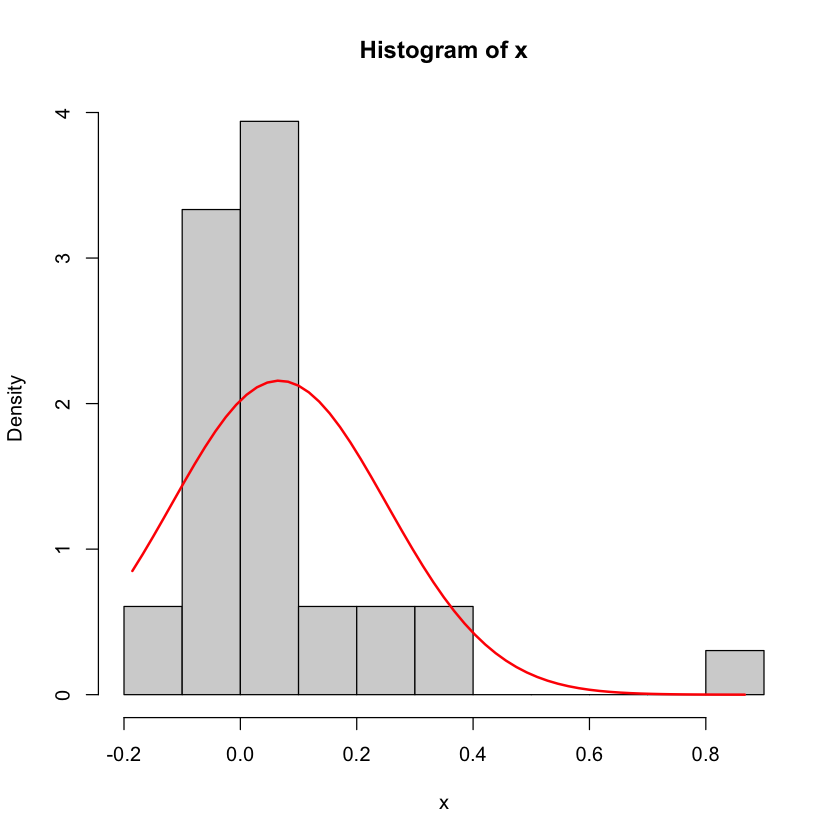

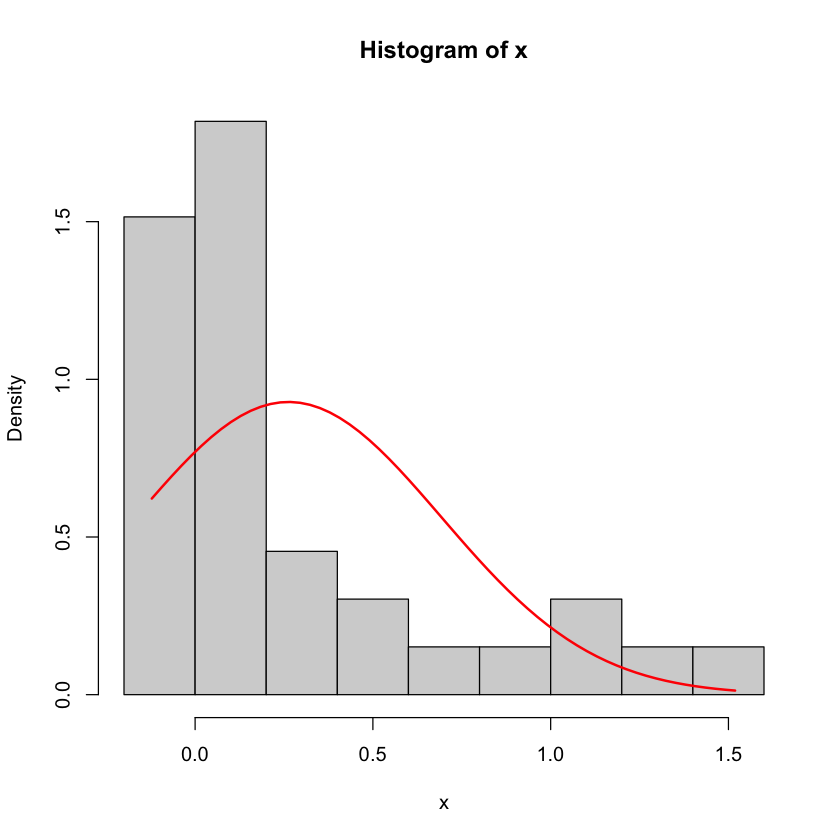

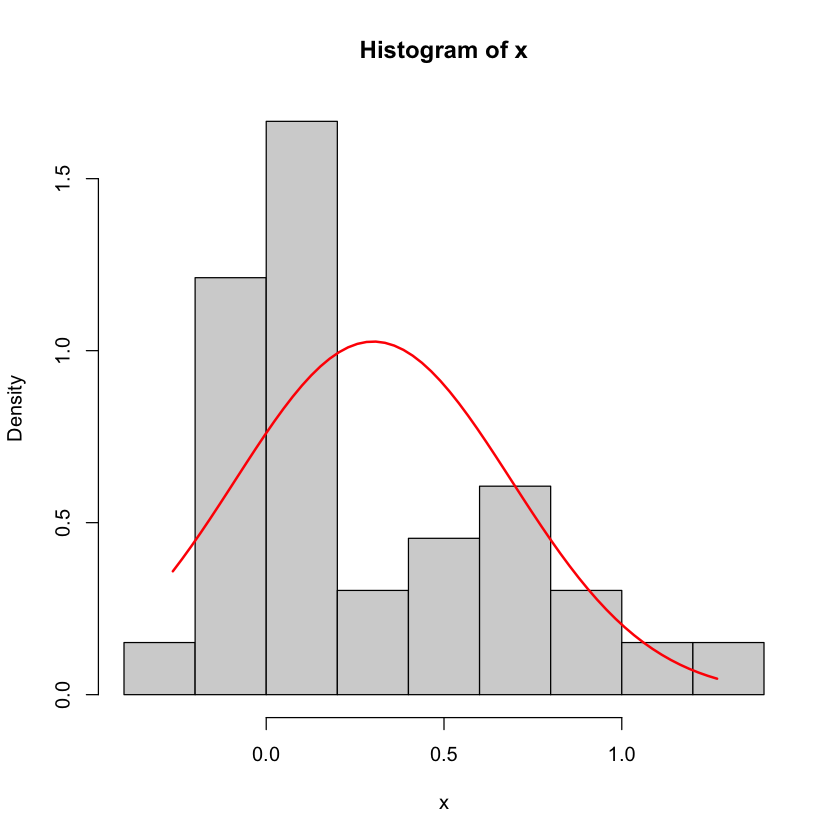

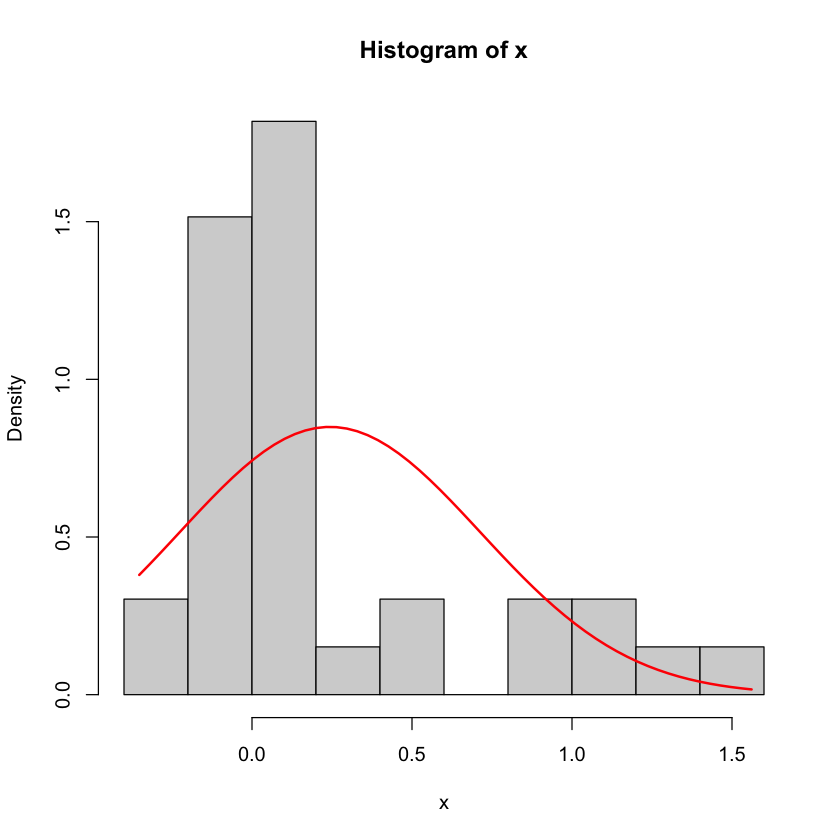

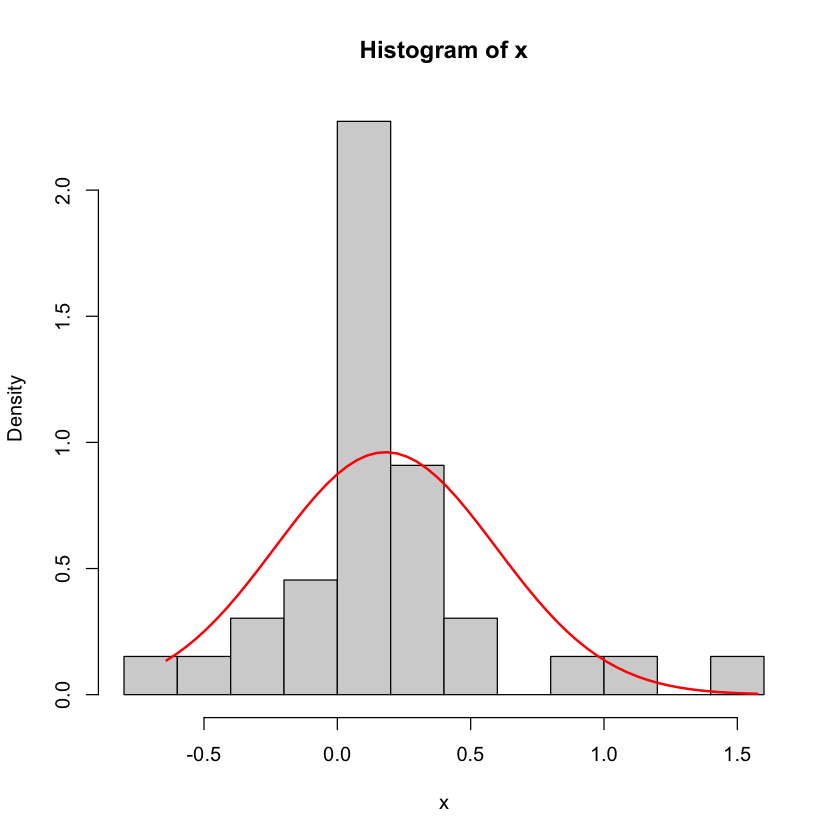

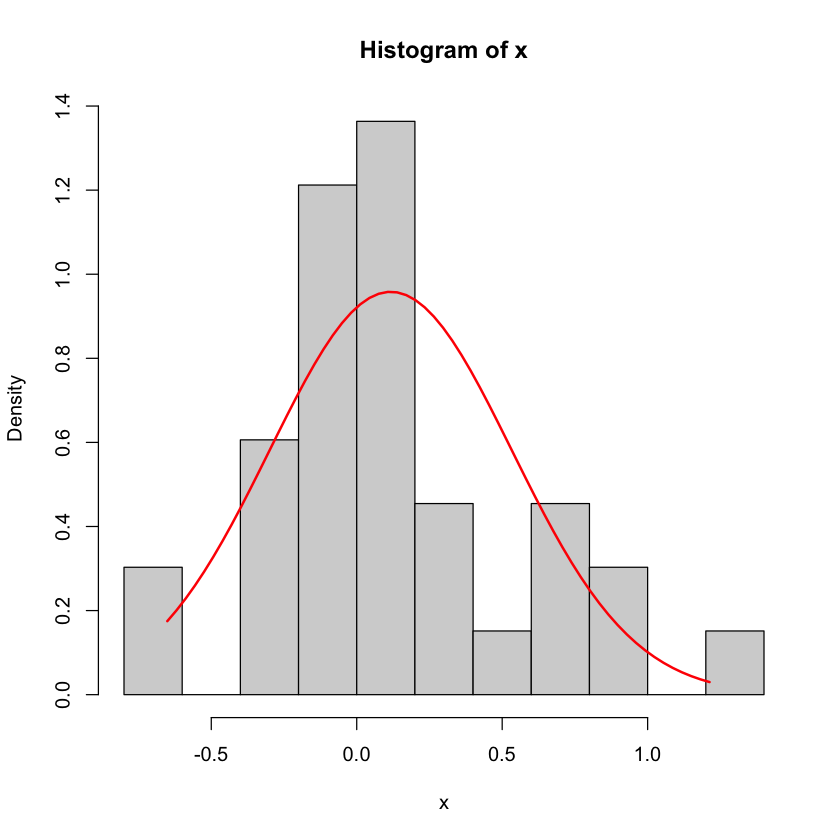

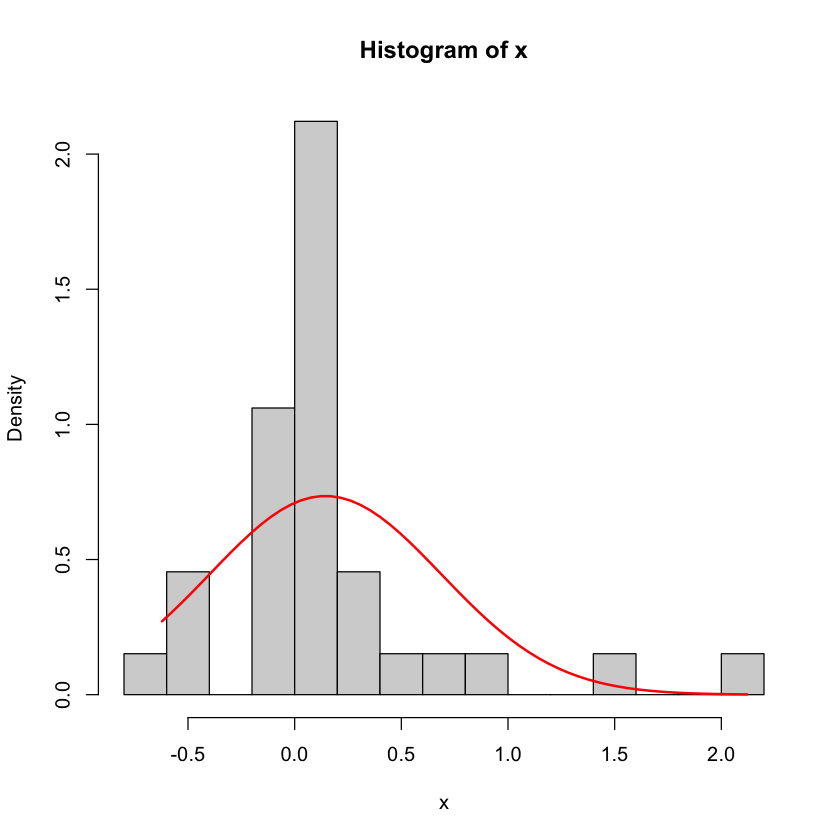

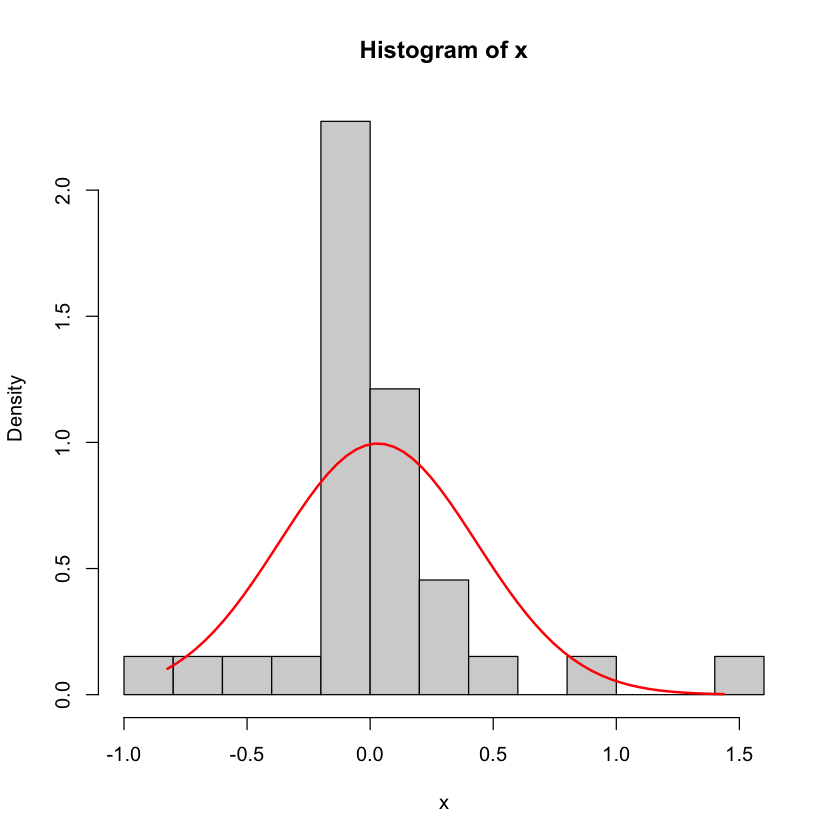

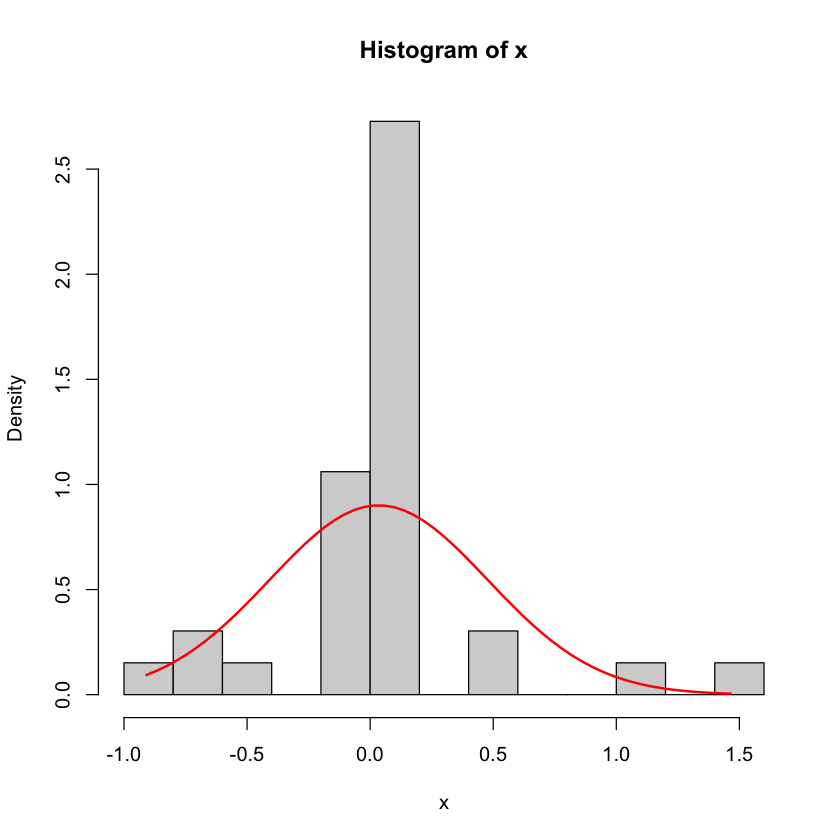

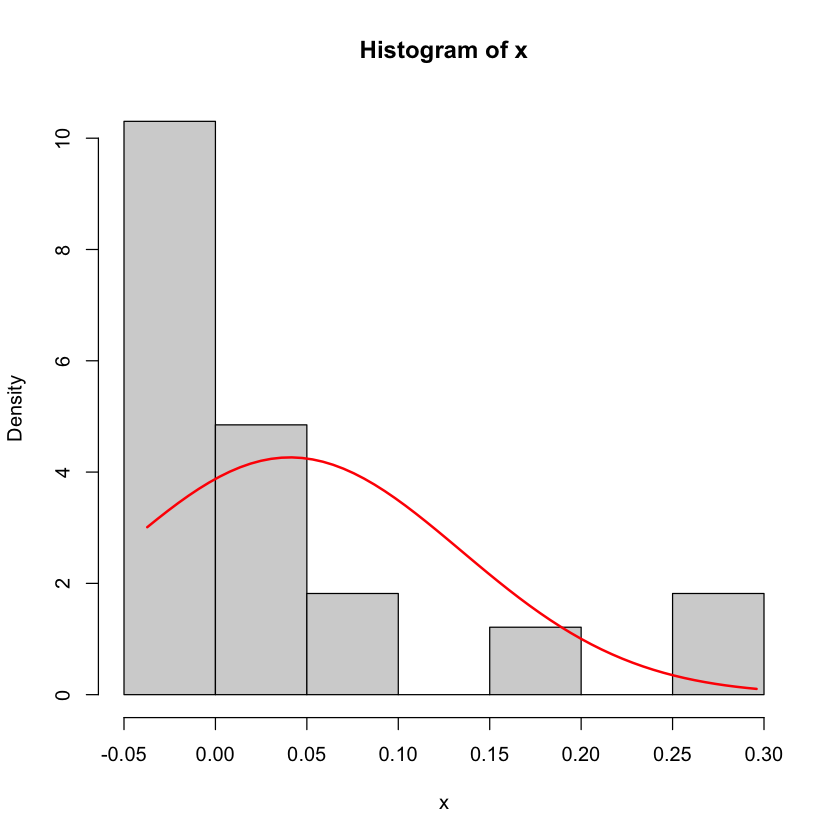

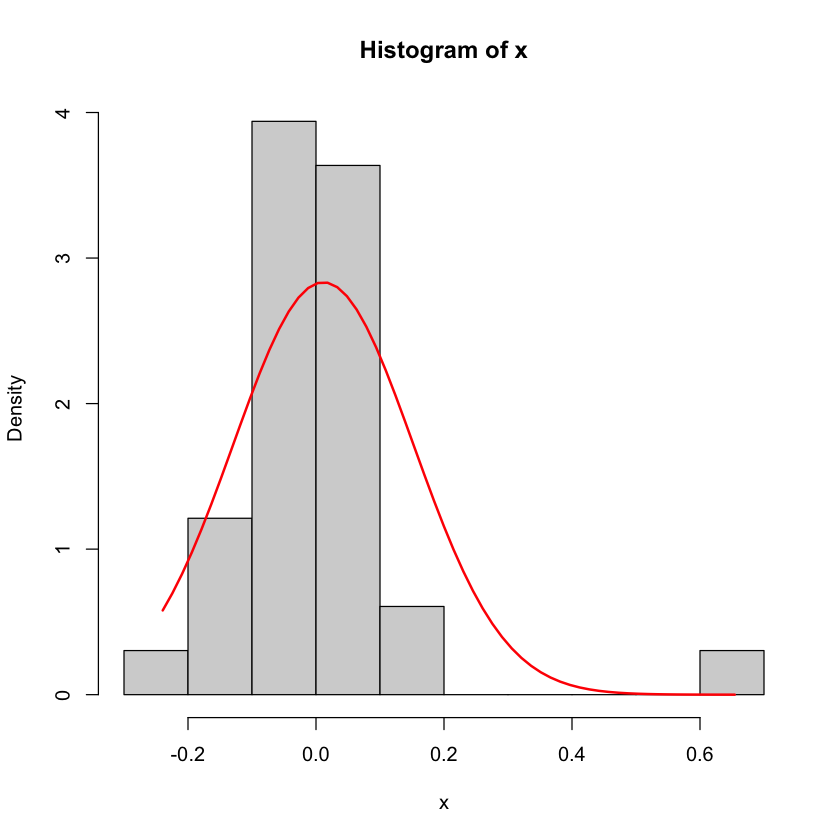

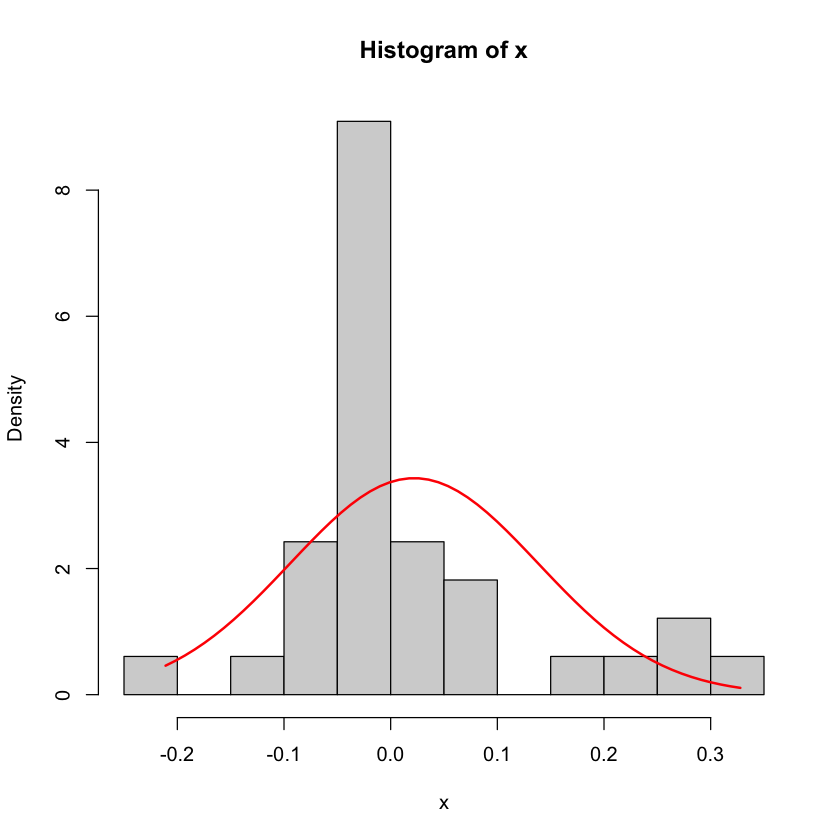

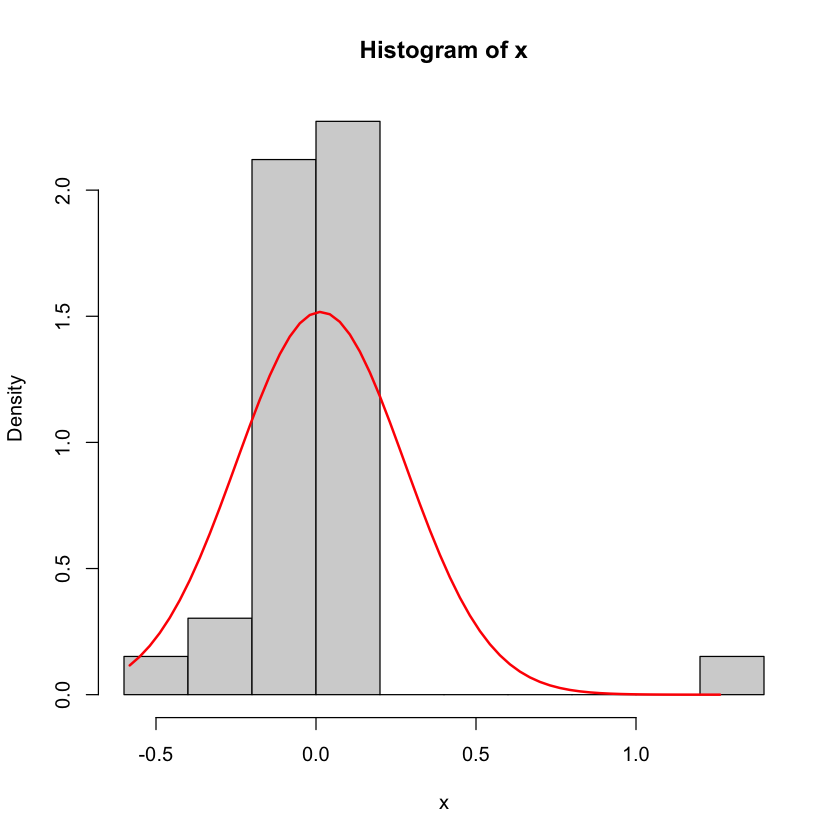

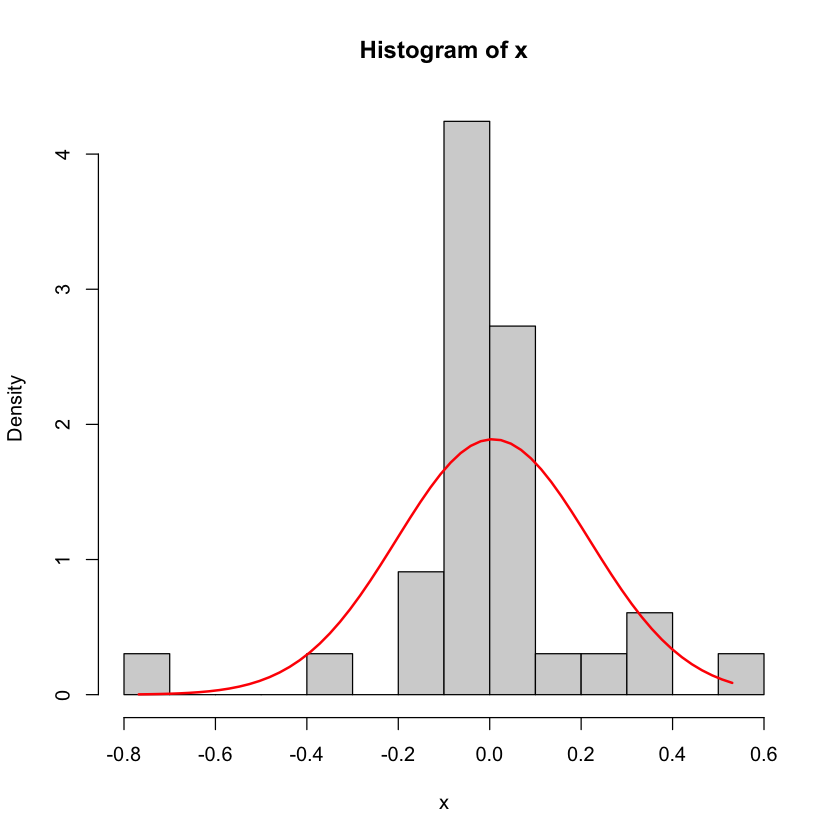

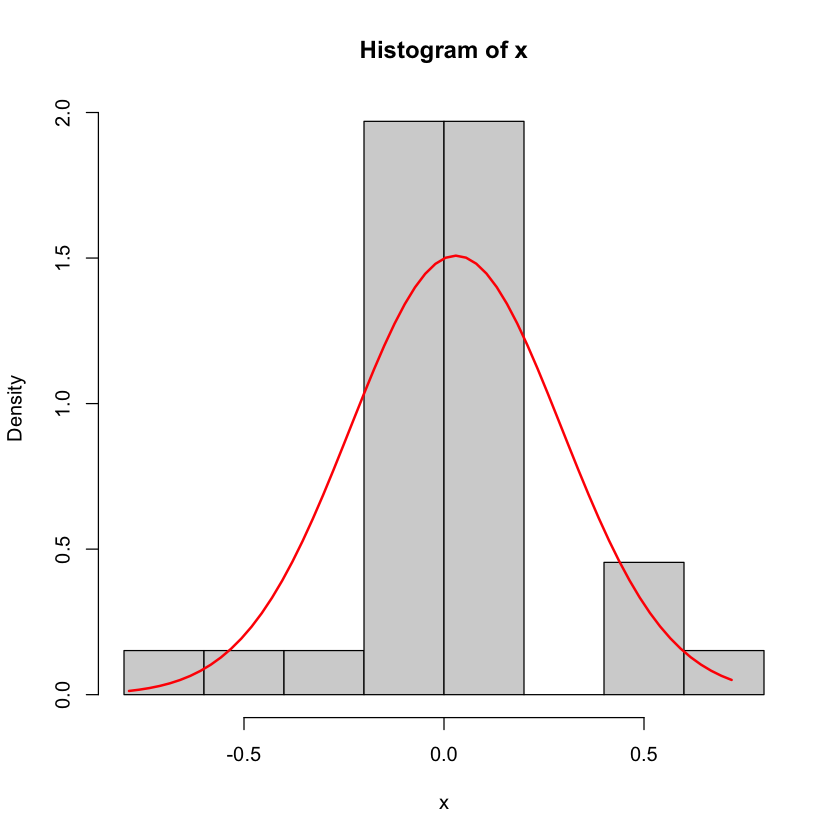

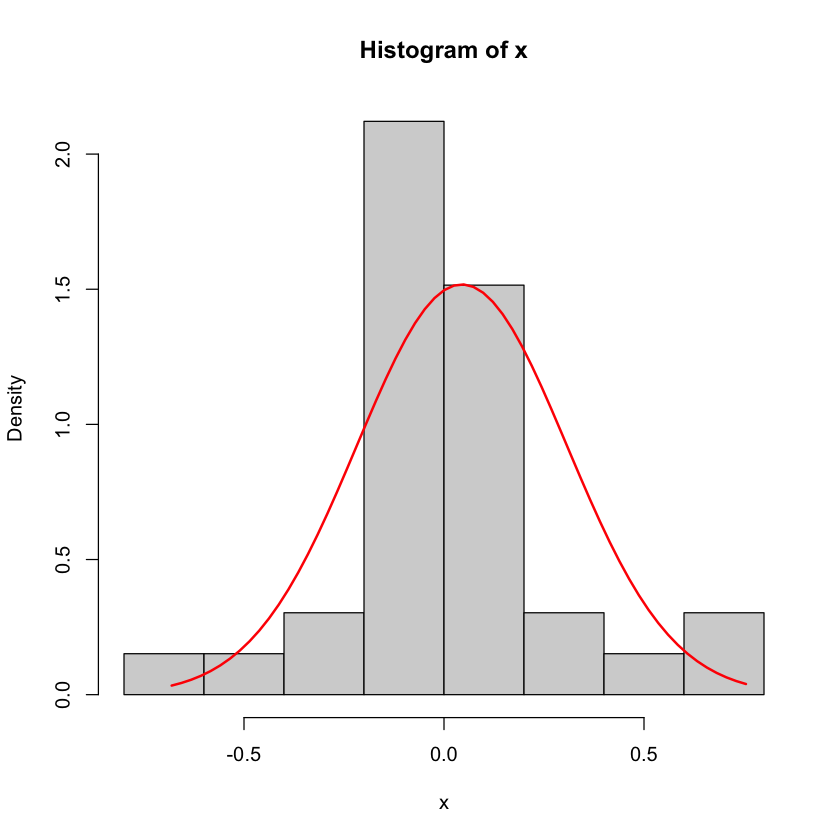

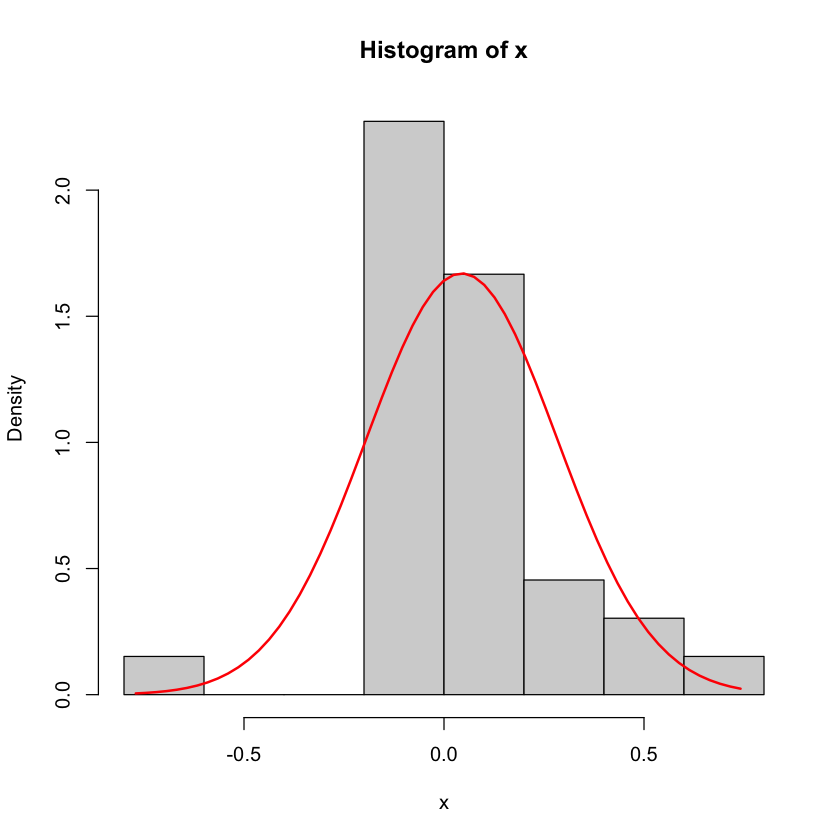

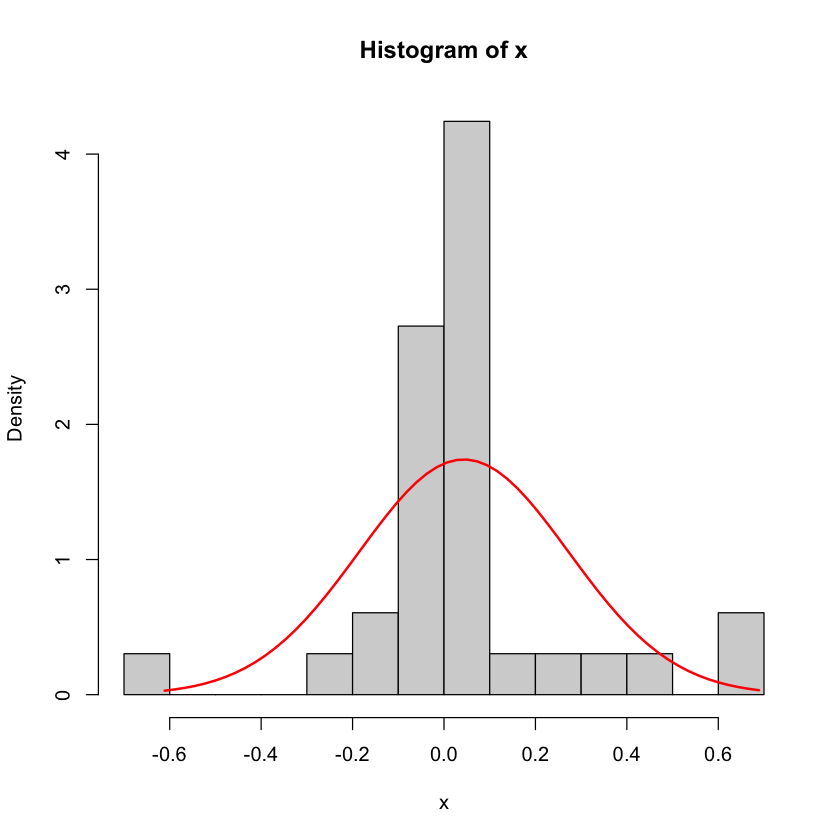

In [4]:
## hist plots for each col of behavioural data (B-splines coeffs), no normalisation on B-splines (data was normalised prior to doing FDA):
for(i in colnames(behaviour)){
    x <- behaviour[, i]
    x2 <- seq(min(x), max(x), length = 60)
    dens <- dnorm(x2, mean(x), sd(x))
    hist(x, breaks = 10, prob = TRUE)
    lines(x2, dens, col = "red", type = "l", lwd = 2)
}

#### 2. Classification comportement via GMM
=> pas besoin de normaliser les données comme elles l'ont déjà été précédemment

UPDATE: scale them.

RQ: feature engineering à peut-être faire en fonction des résultats obtenus

In [5]:
X_scaled <- scale(behaviour)

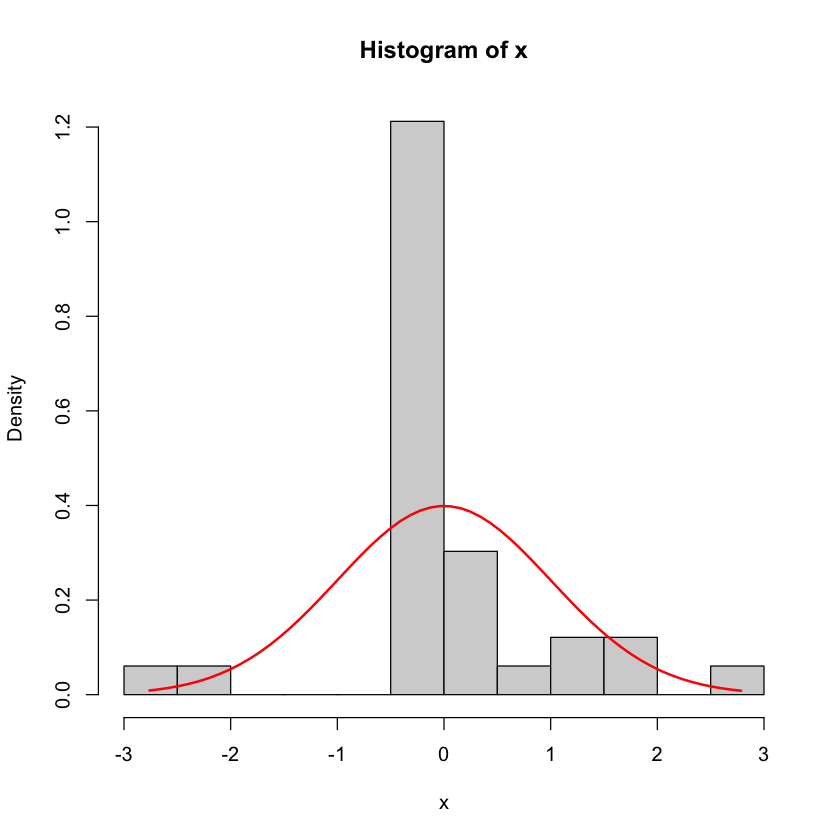

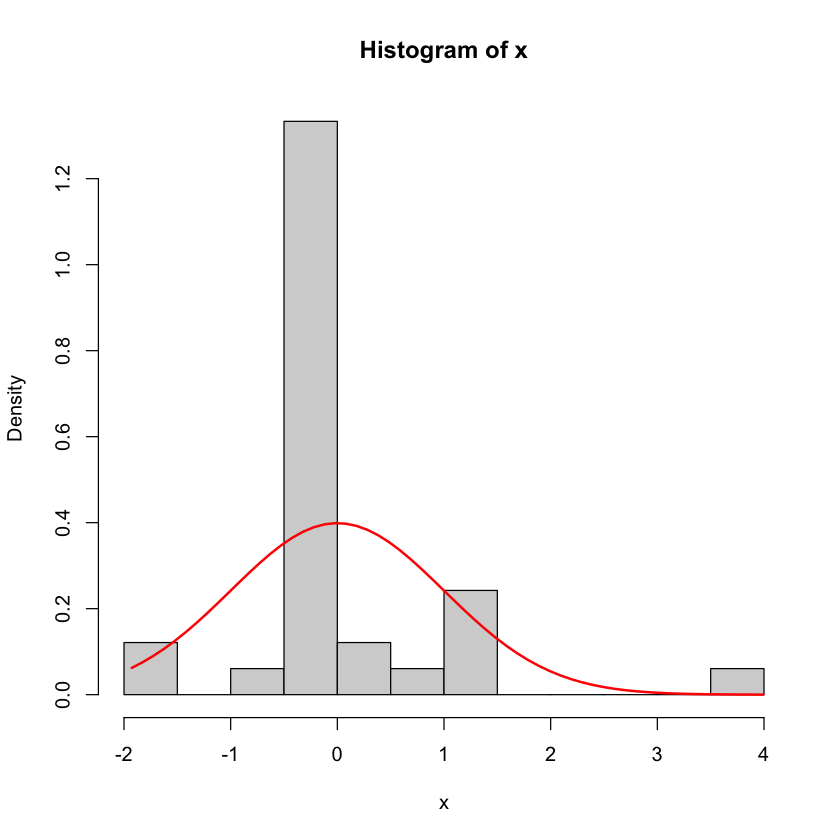

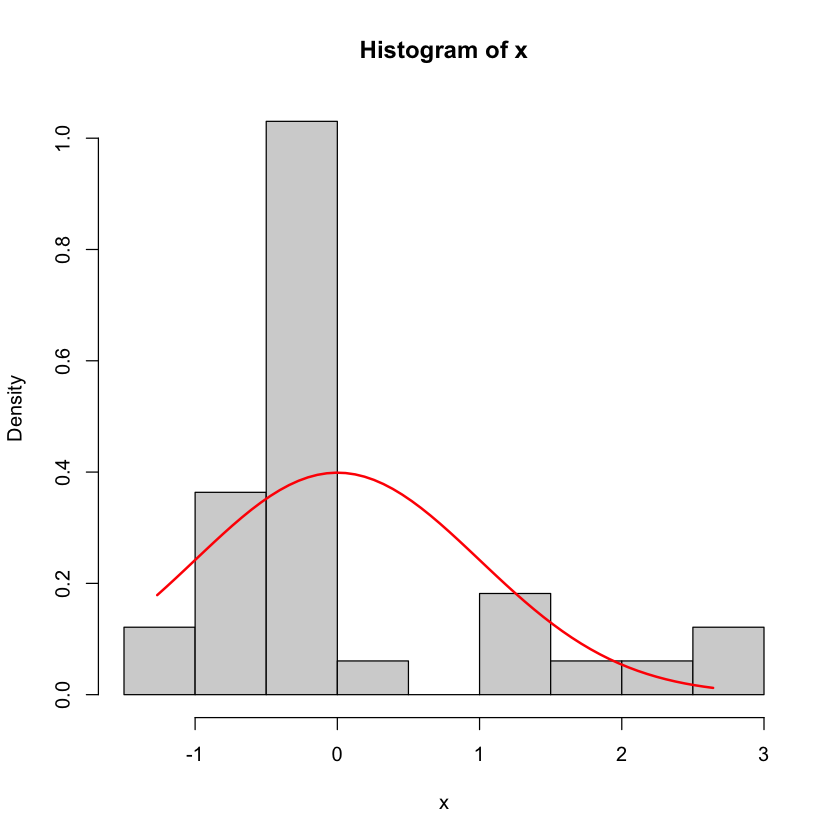

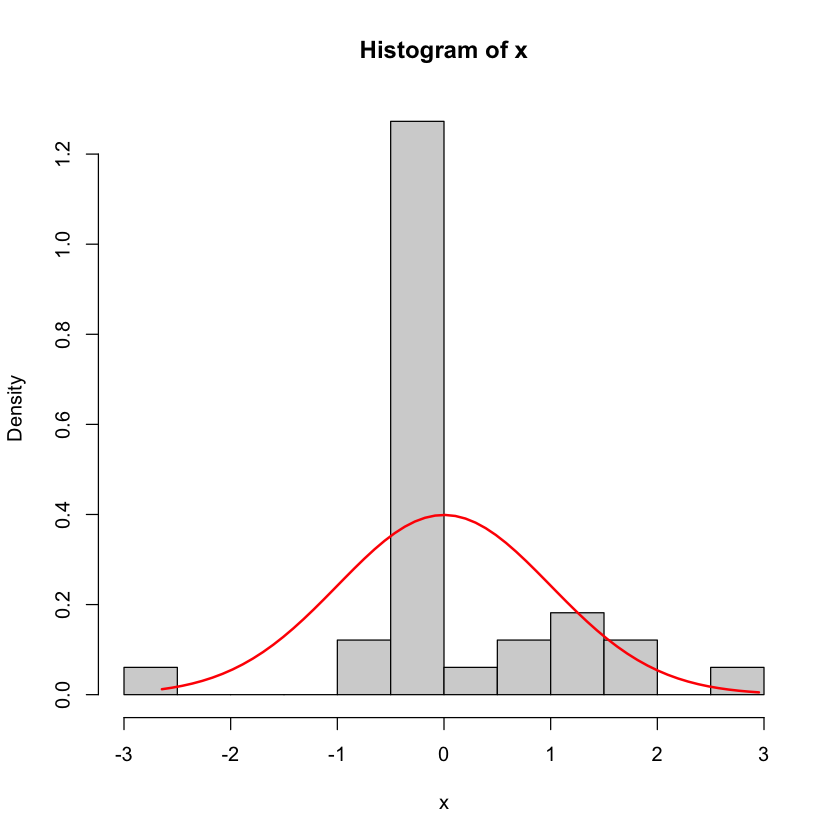

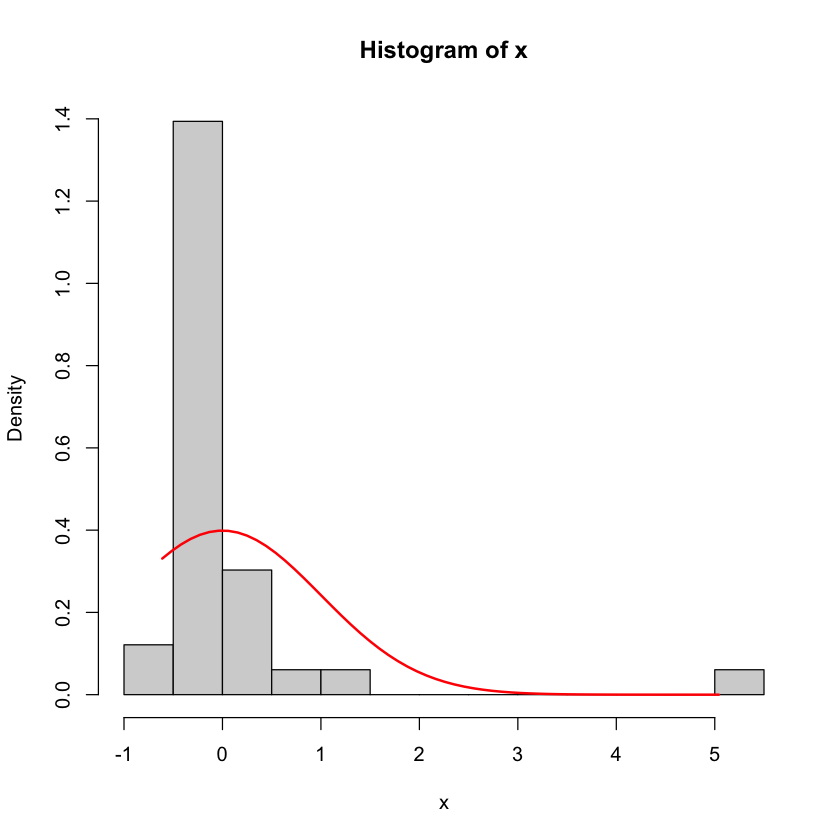

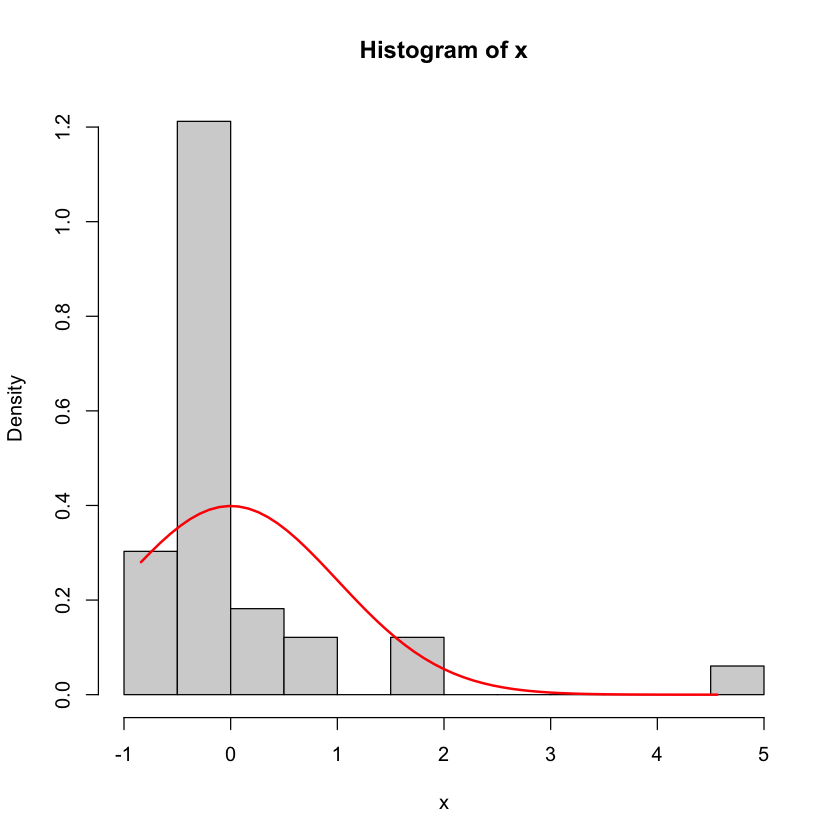

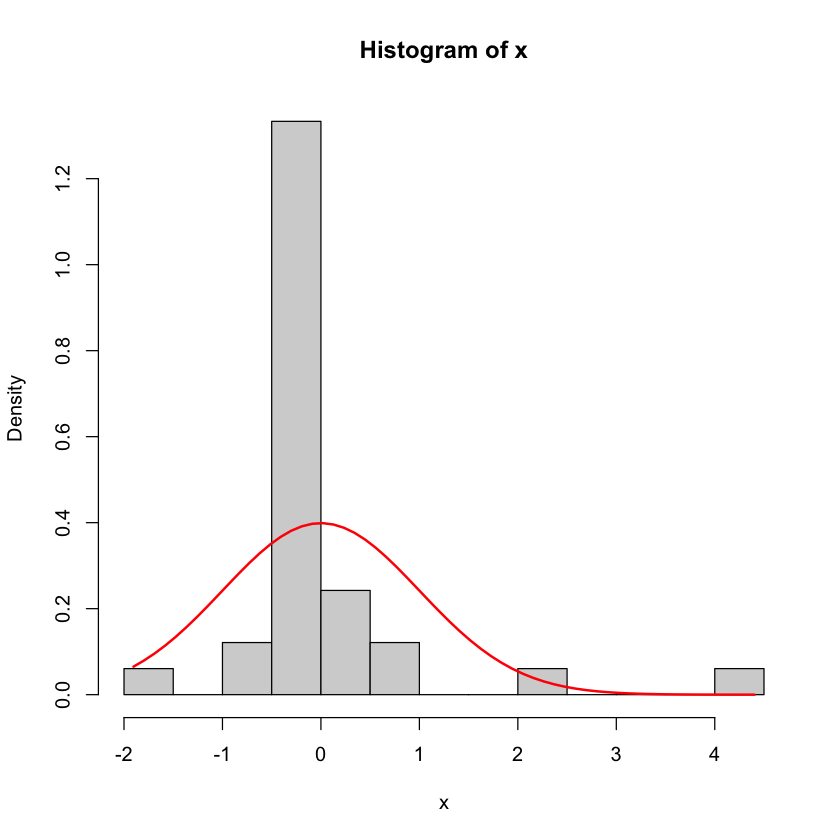

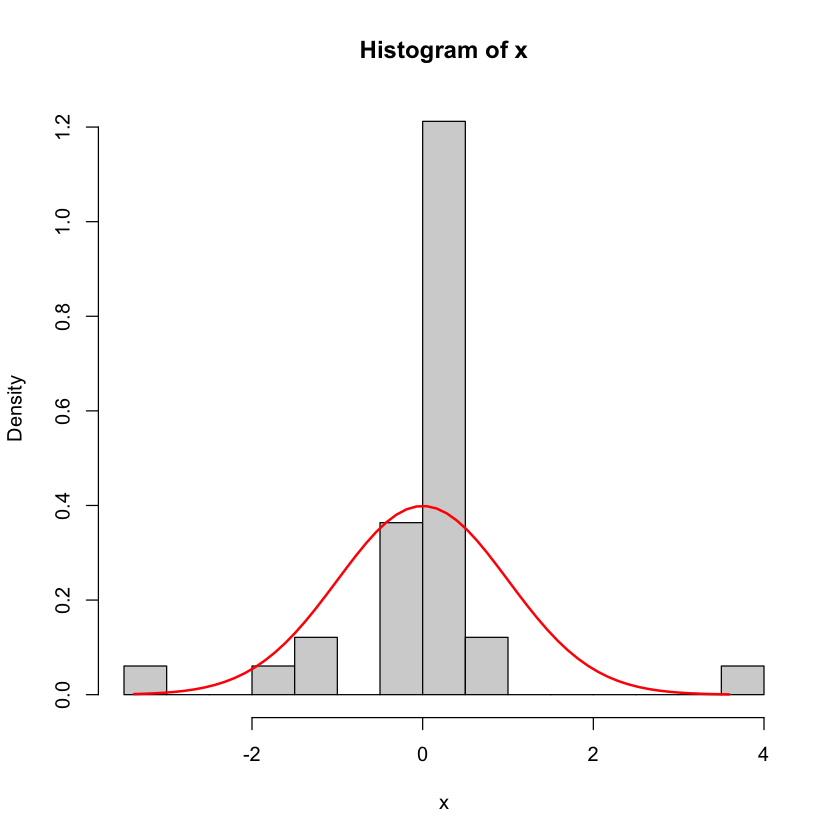

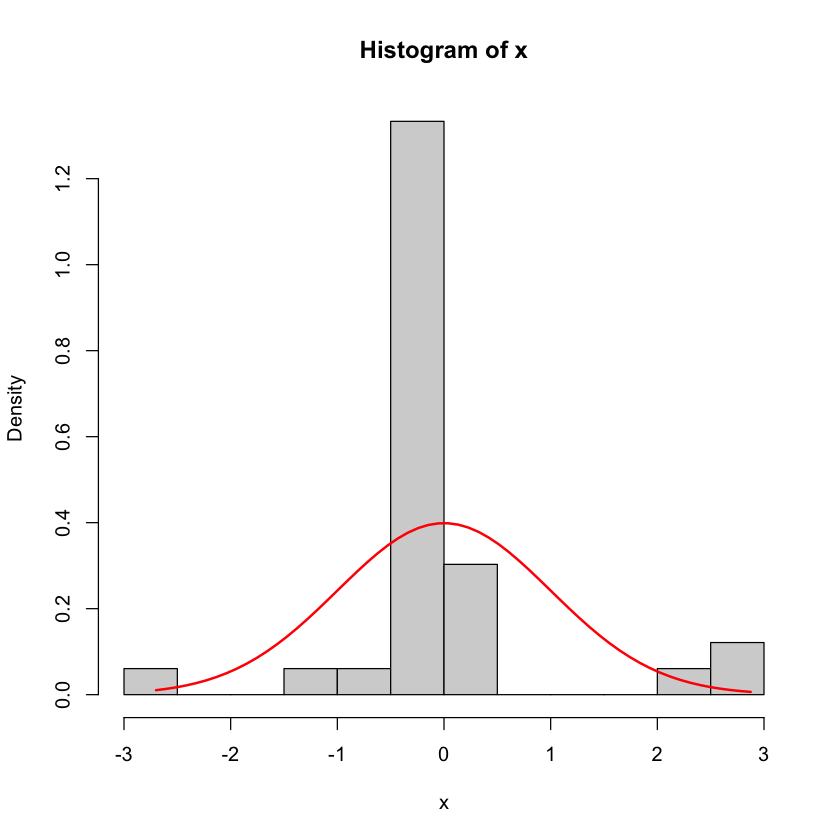

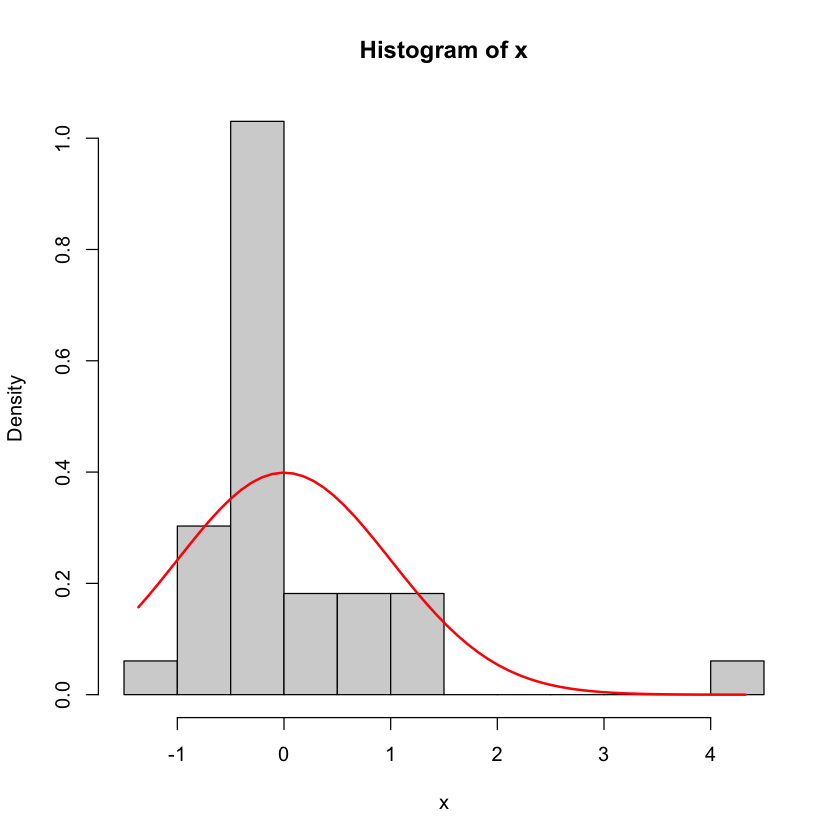

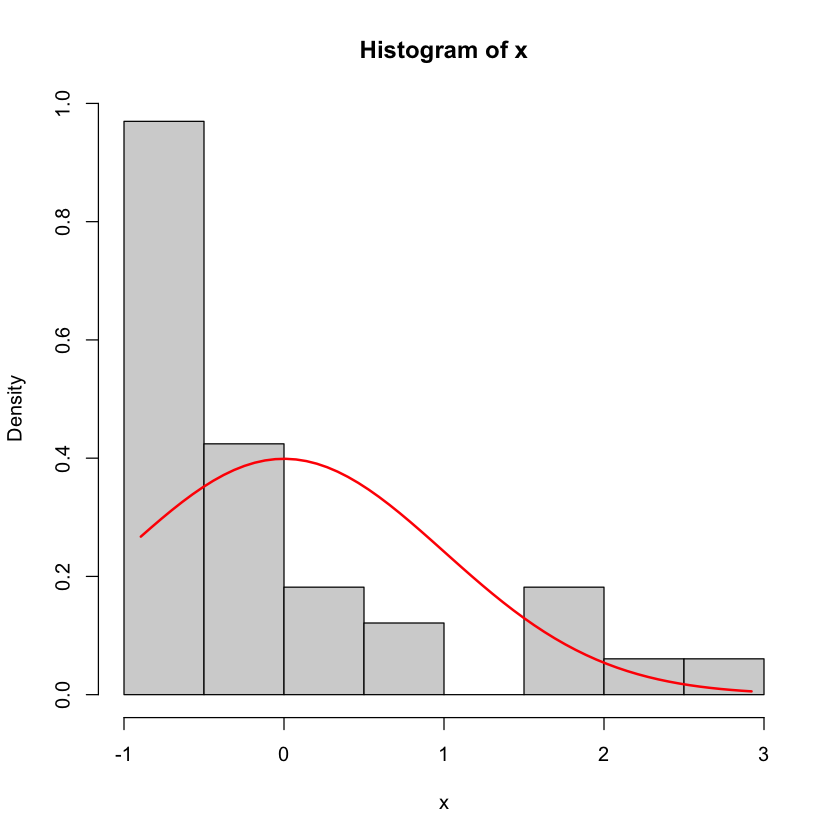

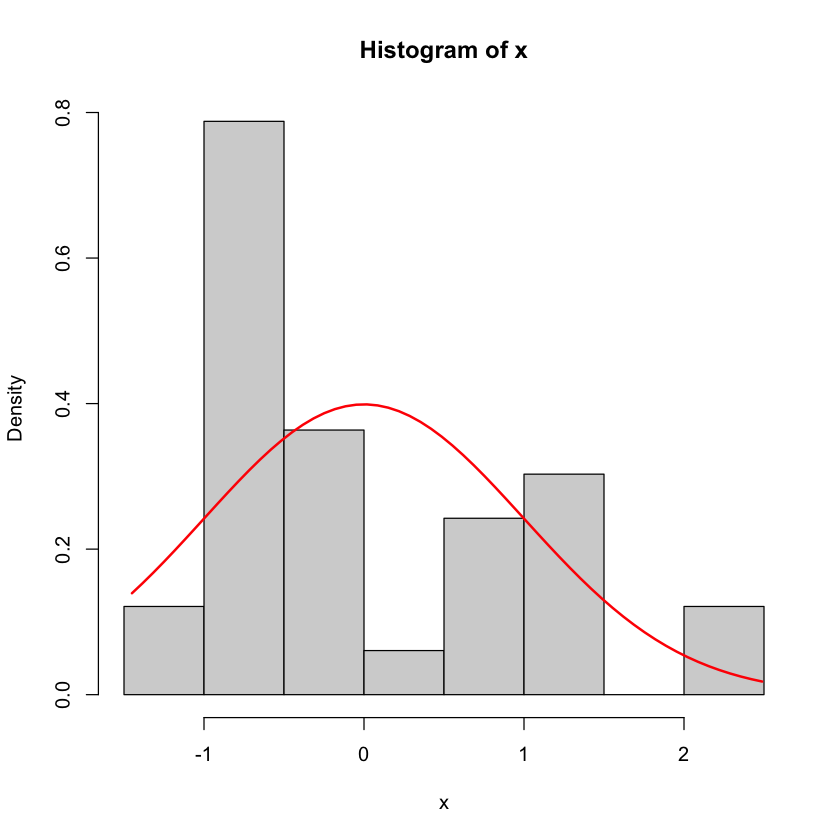

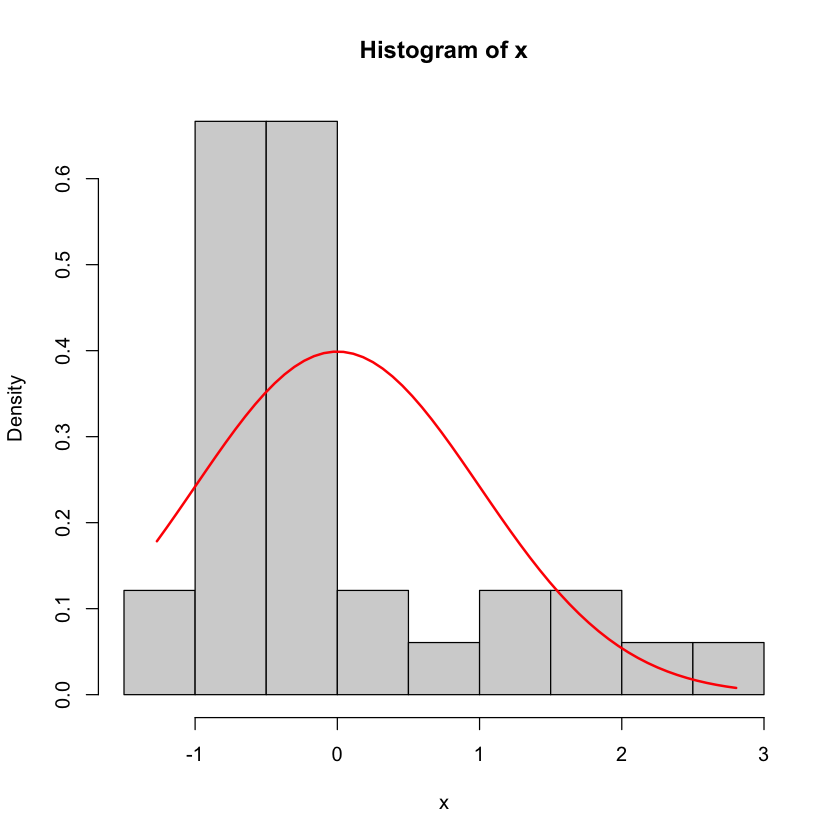

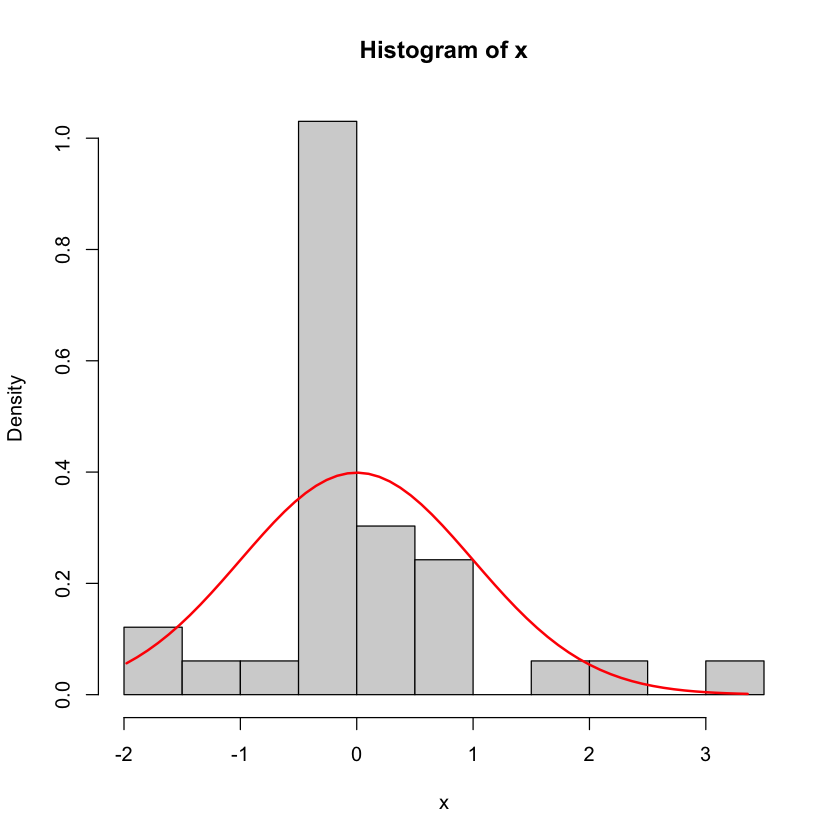

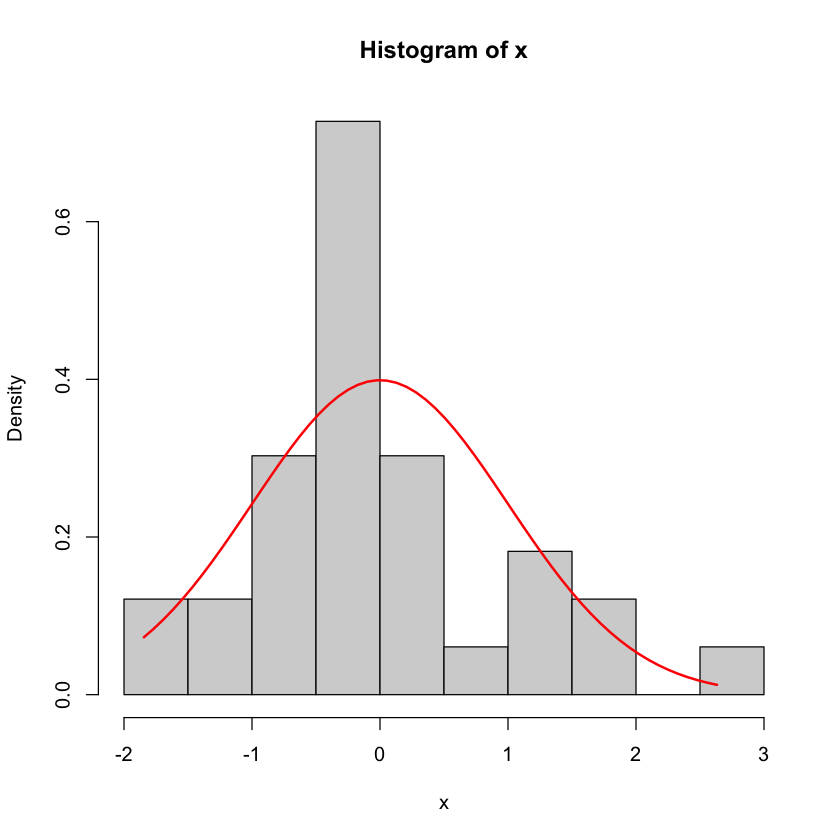

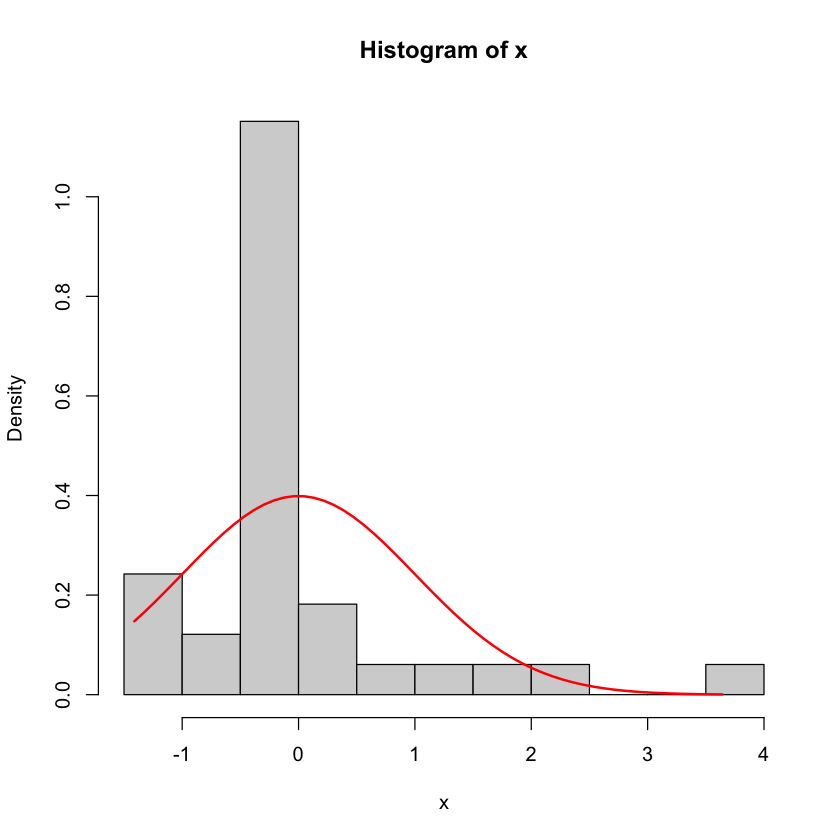

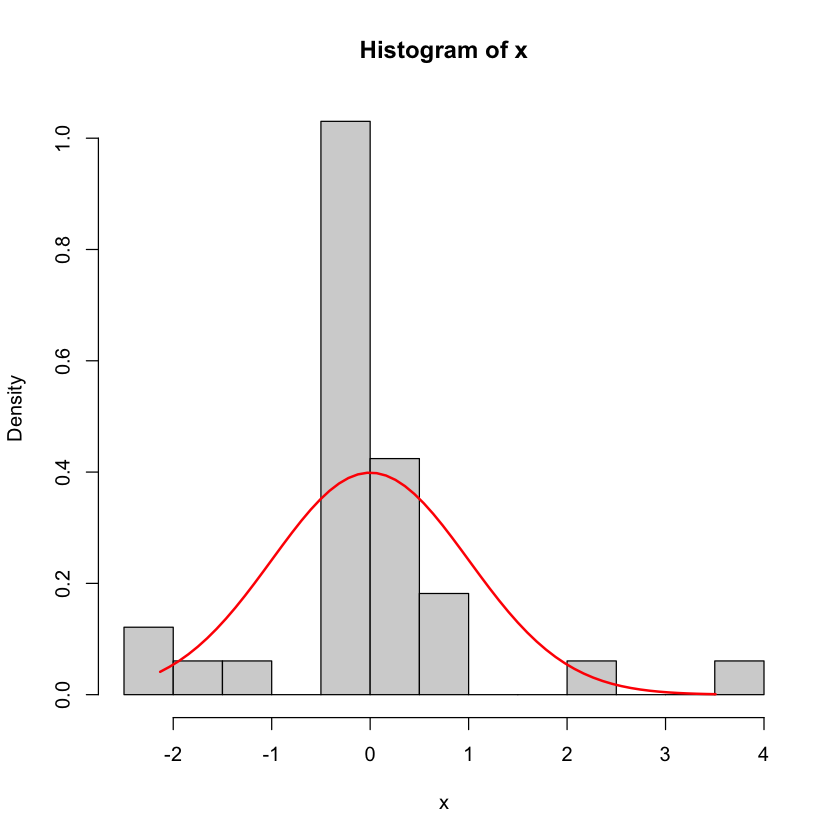

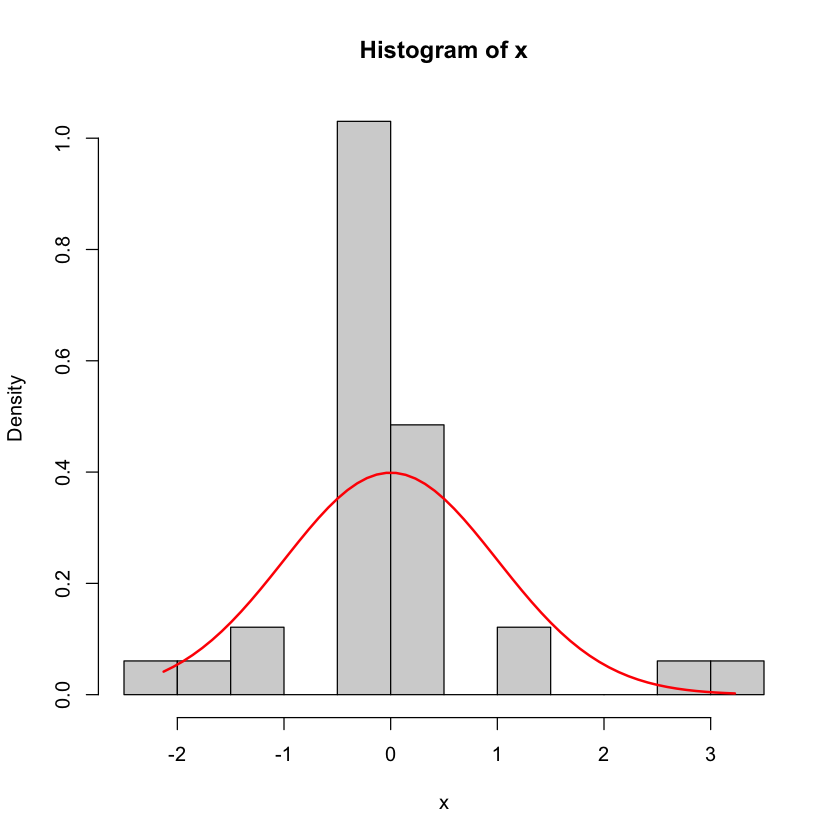

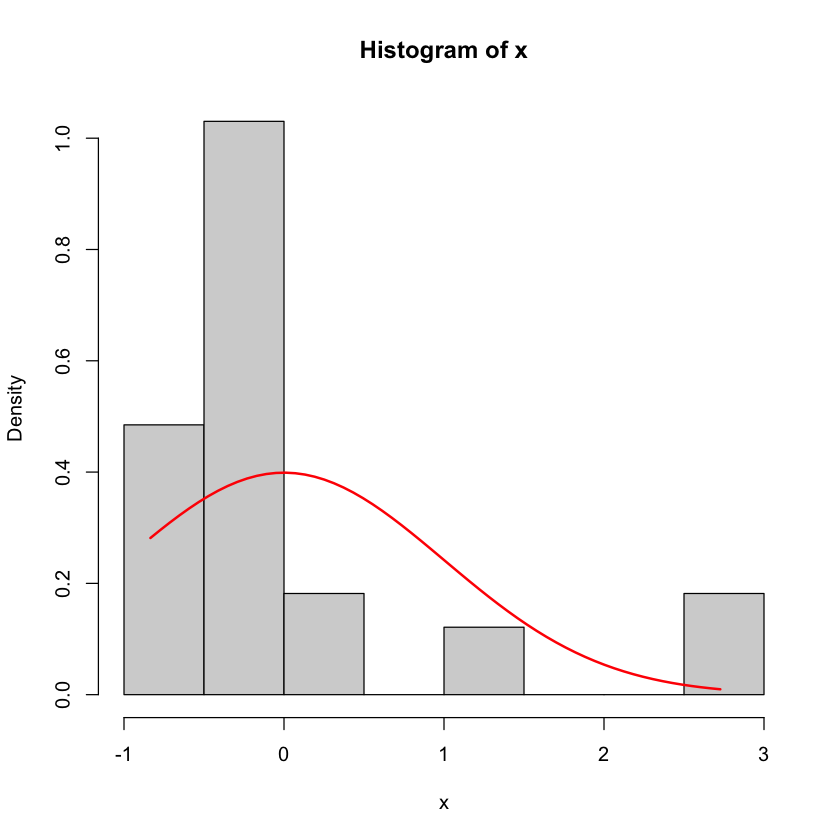

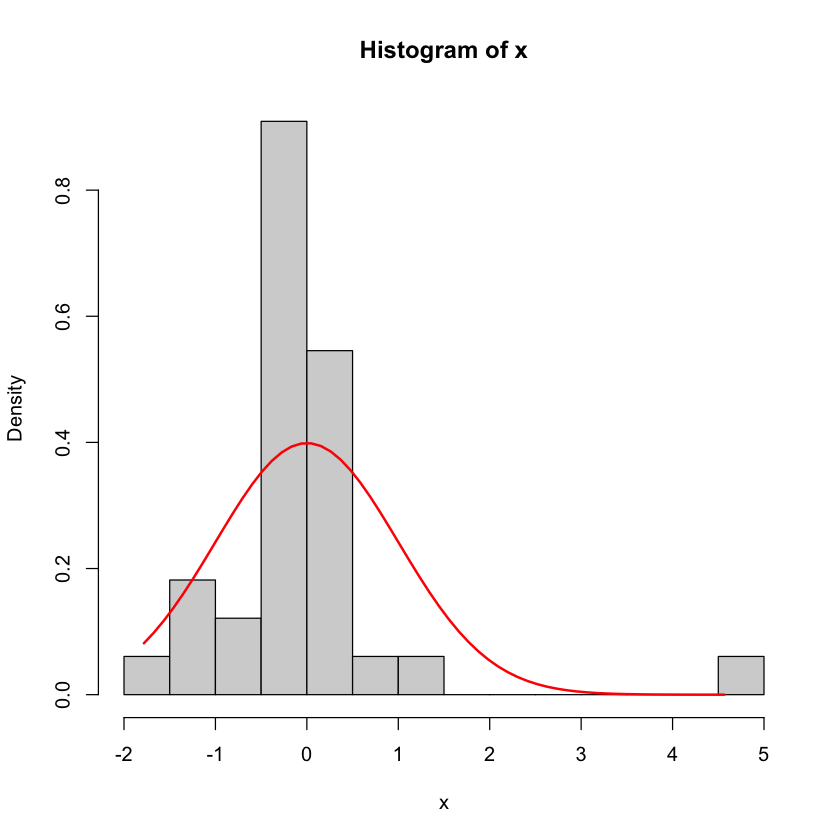

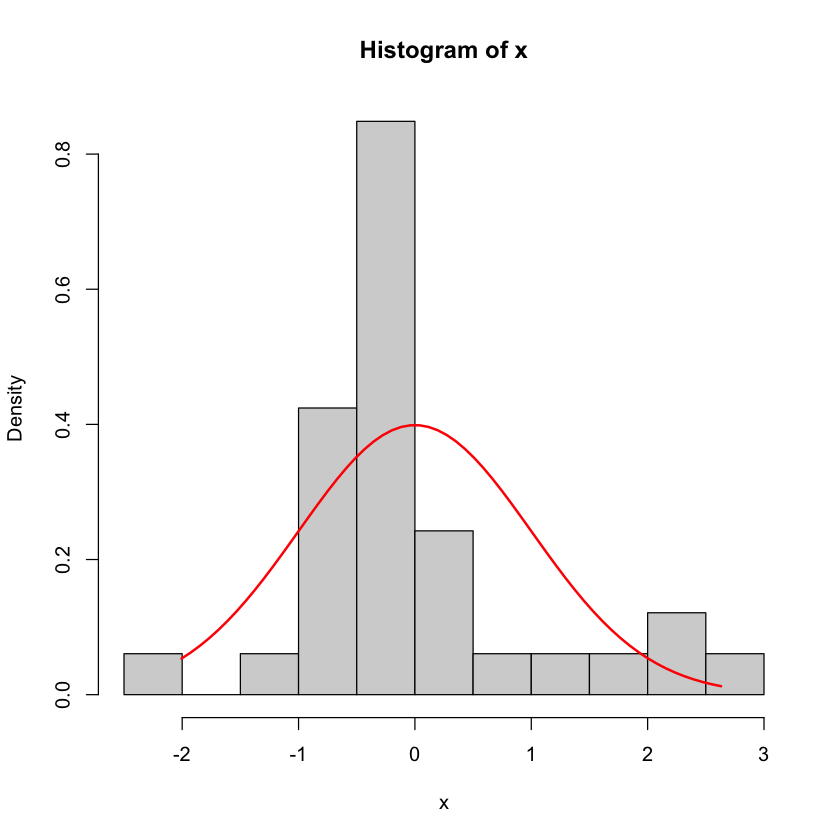

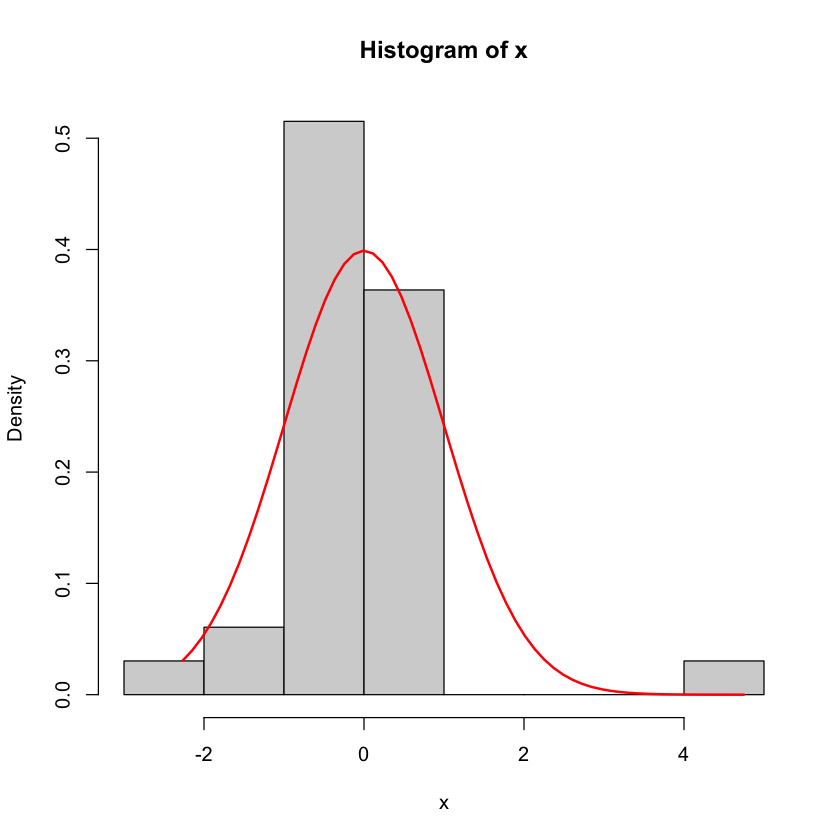

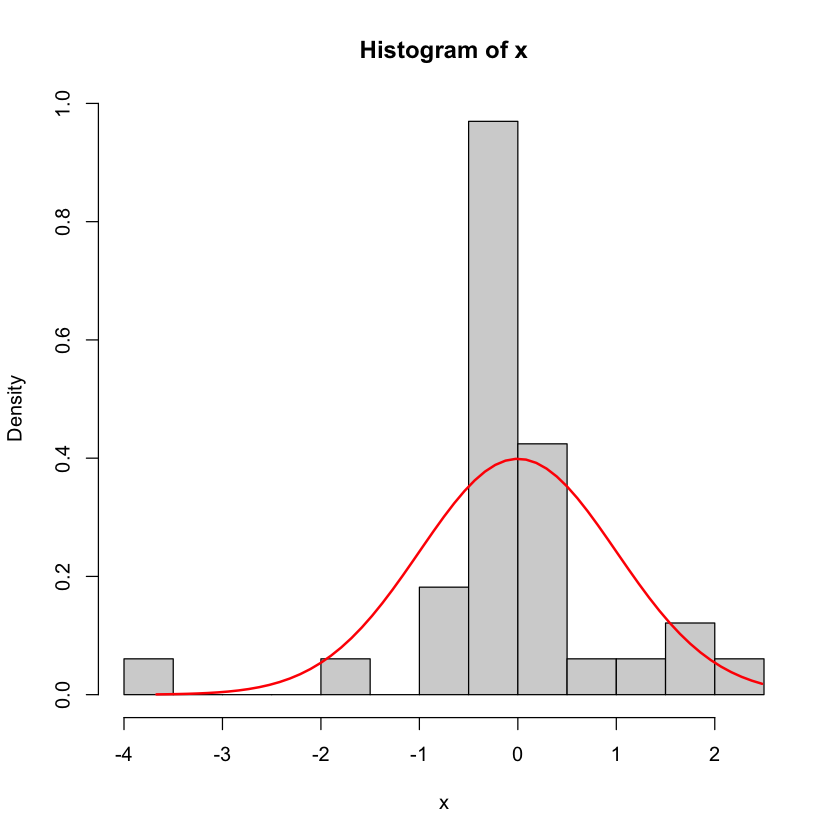

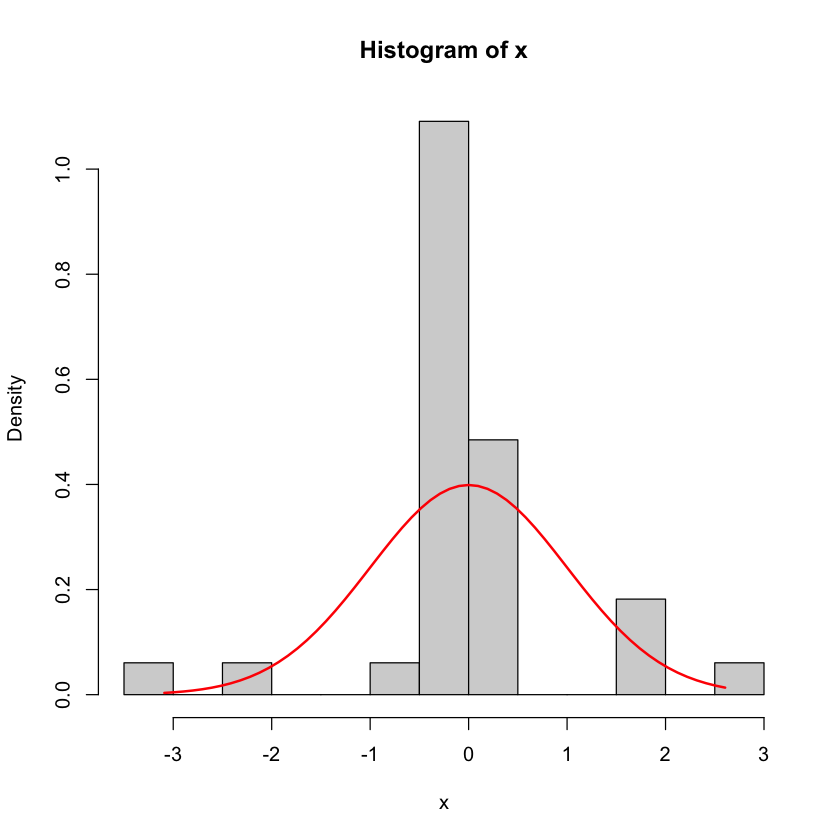

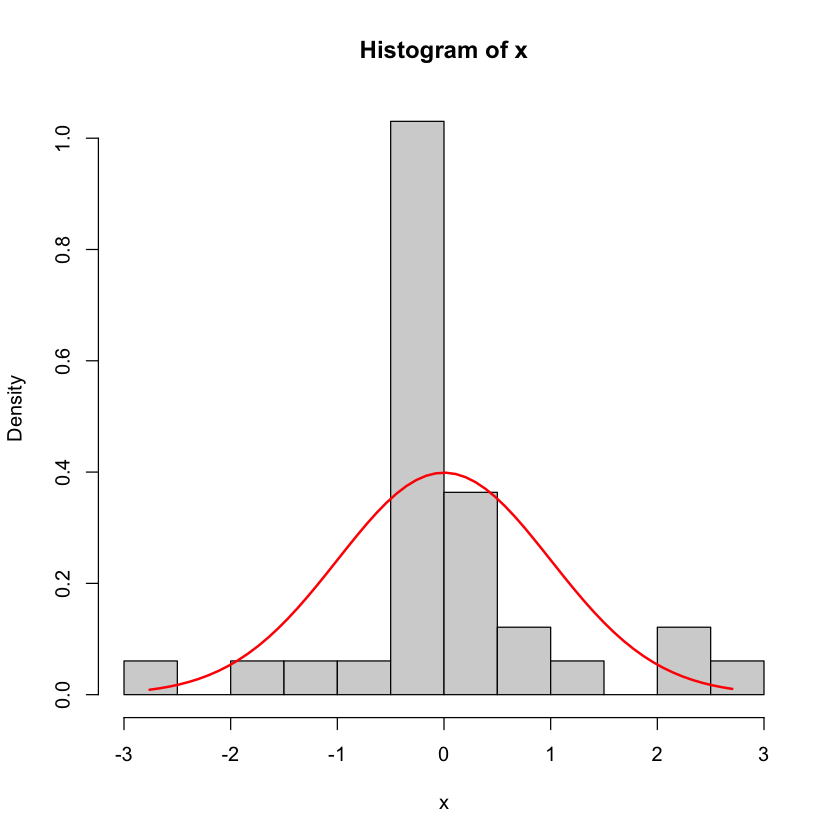

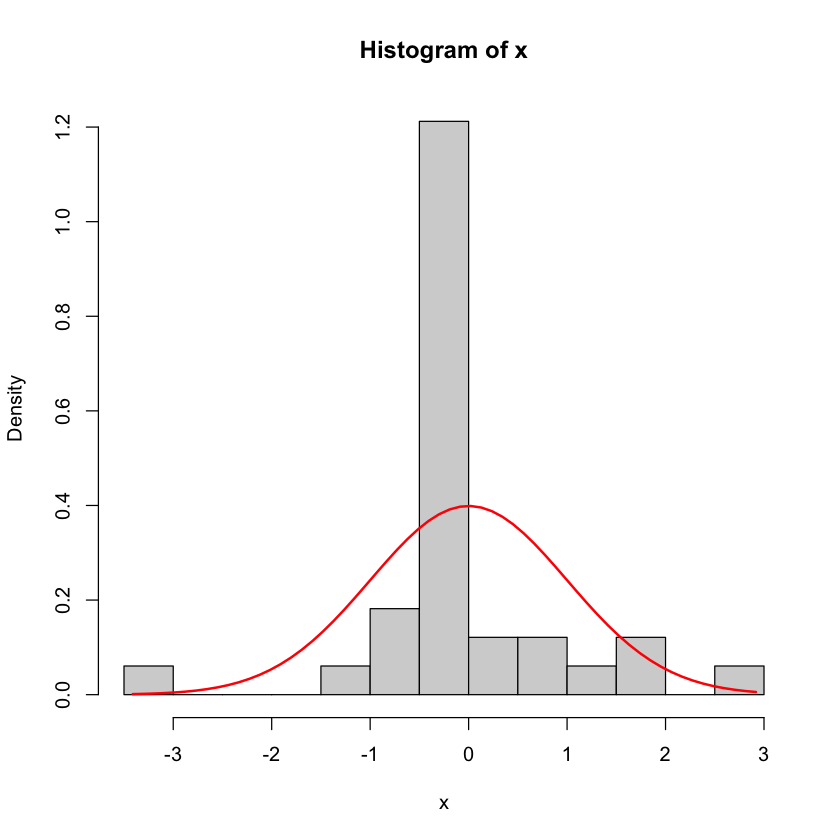

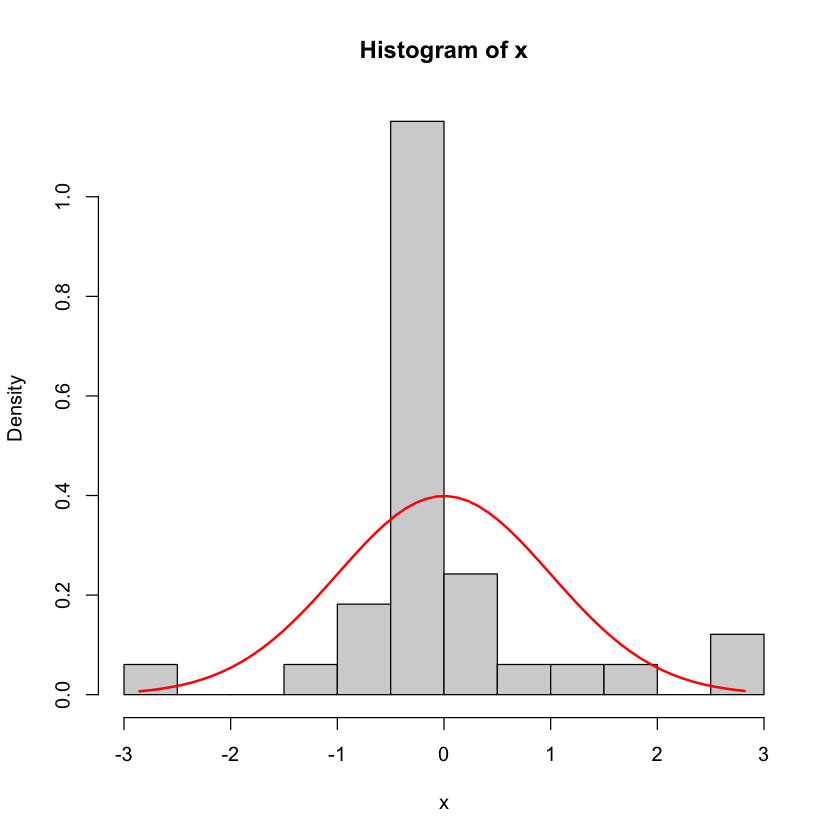

In [6]:
for(i in colnames(X_scaled)){
    x <- X_scaled[, i]
    x2 <- seq(min(x), max(x), length = 60)
    dens <- dnorm(x2, mean(x), sd(x))
    hist(x, breaks = 10, prob = TRUE)
    lines(x2, dens, col = "red", type = "l", lwd = 2)
}

##### 2.1: Réduction espace dimensionnel via graphical LASSO

In [7]:
## STEP 1: matrice de covariance
S <- cov(behaviour)

In [8]:
glasso_res <- glasso(S, rho = 0.05) ## rho fixé, à optimiser normalement
Theta <- glasso_res$wi ## matrice de précision estimée

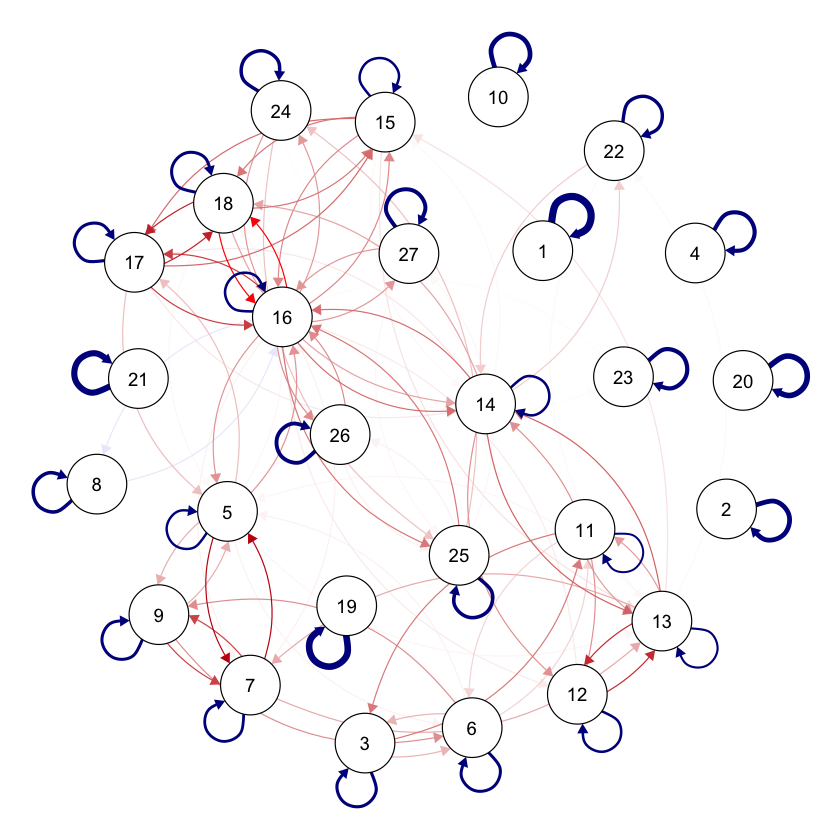

In [9]:
## STEP 2: visualiser le réseau
qgraph(Theta, theme = "colorblind", layout = "spring")

In [10]:
sum(abs(Theta) > 1e-5) - ncol(Theta)

[1] 86

In [11]:
p <- ncol(Theta)
edges <- (sum(abs(Theta) > 1e-5) - p) / 2
max_edges <- p*(p-1)/2

edges / max_edges ## if > 30%, still too dense, so fix lambda // if < 10%, too few so fix lambda

[1] 0.1225071

In [12]:
#### STEP 3: sélection B-splines pertinentes
X_glasso <- rowSums(abs(Theta)) - abs(diag(Theta))

In [13]:
X_keep <- (X_glasso > quantile(X_glasso, 0.2))

In [14]:
X_sel <- behaviour[, X_keep]

In [15]:
head(X_sel)

,bspline_3_1,bspline_5_1,bspline_6_1,bspline_7_1,bspline_8_1,bspline_9_1,bspline_2_2,bspline_3_2,bspline_4_2,bspline_5_2,bspline_6_2,bspline_7_2,bspline_8_2,bspline_9_2,bspline_4_3,bspline_5_3,bspline_6_3,bspline_7_3,bspline_8_3,bspline_9_3
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1-2Dichloroethane,0.5140330488,0.0432431615,0.1191663208,-0.161778078,0.02312422,-0.3382460723,0.6914492647,0.543240084,0.56144343,0.34807031,0.50458026,-0.028732456,0.087622444,0.046915940,-0.311698492,-0.767715644,-0.78753003,-0.68081242,-0.77054578,-0.611039982
1-chlorodecane,-0.0143353314,0.0156677416,0.0116948309,0.060606854,0.07095725,0.0206552934,-0.0097761979,-0.002013117,0.14882597,0.04039040,-0.01167734,0.040562762,0.148953361,0.022286039,0.000000000,0.000000000,0.00000000,0.00000000,0.00000000,0.000000000
124-Trichlorobenzene,0.0275044208,0.0280358371,-0.0105425596,0.011499964,0.01142211,0.0028426074,0.4787486315,0.161352896,0.09186130,-0.01883218,0.05138594,0.001050664,-0.008550808,0.004155809,0.006867849,0.007203797,-0.03415222,0.13256952,0.02025038,0.100817682
4-octylphenol,0.4688403629,2.3234831092,0.6141764850,1.787215174,-0.47782508,0.9492905666,0.3079186364,0.739378532,1.13754533,1.13880220,0.91701101,2.121813035,1.436714856,1.463942855,0.119775167,0.269533574,0.45472705,0.75486122,0.74136268,0.656515341
A736,0.0002881707,0.0005435396,-0.0005483989,0.001493525,-0.01689305,0.0002838245,0.1505727982,0.026174119,-0.02632313,0.01447147,0.01253565,0.011108294,-0.010696775,0.004387048,0.000000000,0.000000000,0.00000000,0.02151884,-0.01236712,0.004480931
Acetone,-0.2286078720,0.2982836627,0.0379303268,0.193872492,-0.03598312,0.0639831126,0.0001207068,-0.006768906,0.02934178,0.03969116,0.10760855,-0.058917514,0.055642037,-0.006512883,0.043701629,-0.120702916,-0.05173680,-0.04268549,-0.12009924,0.066707120


##### 2.2: Application modèles GMM:

In [16]:
## GMM automatique:
set.seed(42)
gmm_optim_K5 <- Mclust(unique(X_sel))
summary(gmm_optim_K5)

---------------------------------------------------- 
Gaussian finite mixture model fitted by EM algorithm 
---------------------------------------------------- 

Mclust VEI (diagonal, equal shape) model with 2 components: 

 log-likelihood  n df       BIC       ICL
       99.87532 33 62 -17.03283 -17.03311

Clustering table:
 1  2 
16 17 

In [17]:
png('../plots/classif_plot_K5.png', width = 3000, height = 2500, res = 300)
plot(gmm_optim_K5, what = 'classification', dimens = 1:3)
dev.off()

agg_record_9f7672c22247 
                      2

In [18]:
## forcing GMM avec classes G (K=9) pour voir si similarités:
set.seed(42)
gmm_optim_K7 <- Mclust(X_sel, G = 6)
summary(gmm_optim_K7)

---------------------------------------------------- 
Gaussian finite mixture model fitted by EM algorithm 
---------------------------------------------------- 

Mclust EEE (ellipsoidal, equal volume, shape and orientation) model with 6
components: 

 log-likelihood  n  df       BIC      ICL
       529.5888 33 335 -112.1524 -112.154

Clustering table:
 1  2  3  4  5  6 
 1 13  1 16  1  1 

In [19]:
png('../plots/classif_plot_K7.png', width = 3000, height = 2500, res = 300)
plot(gmm_optim_K7, what = 'uncertainty', dimens = 1:3)
dev.off()

agg_record_9f7613d48c1 
                     2

In [20]:
gmm_optim_K5$uncertainty[gmm_optim_K5$uncertainty > 0.0001]

L1000 
0.0001388018

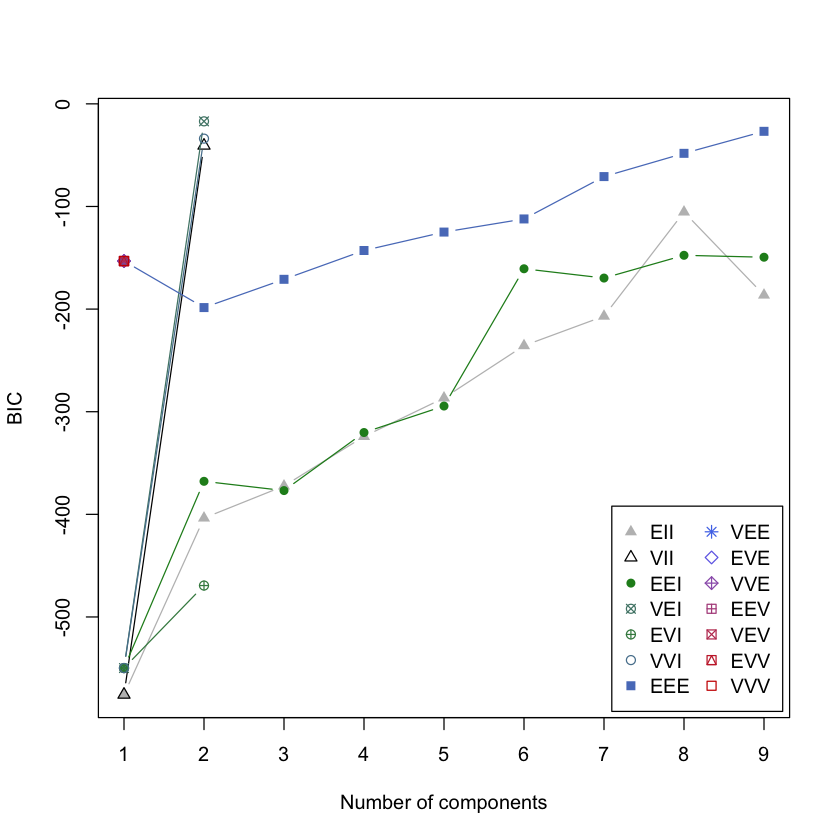

In [21]:
bic_model <- mclustBIC(X_sel)
plot(bic_model)

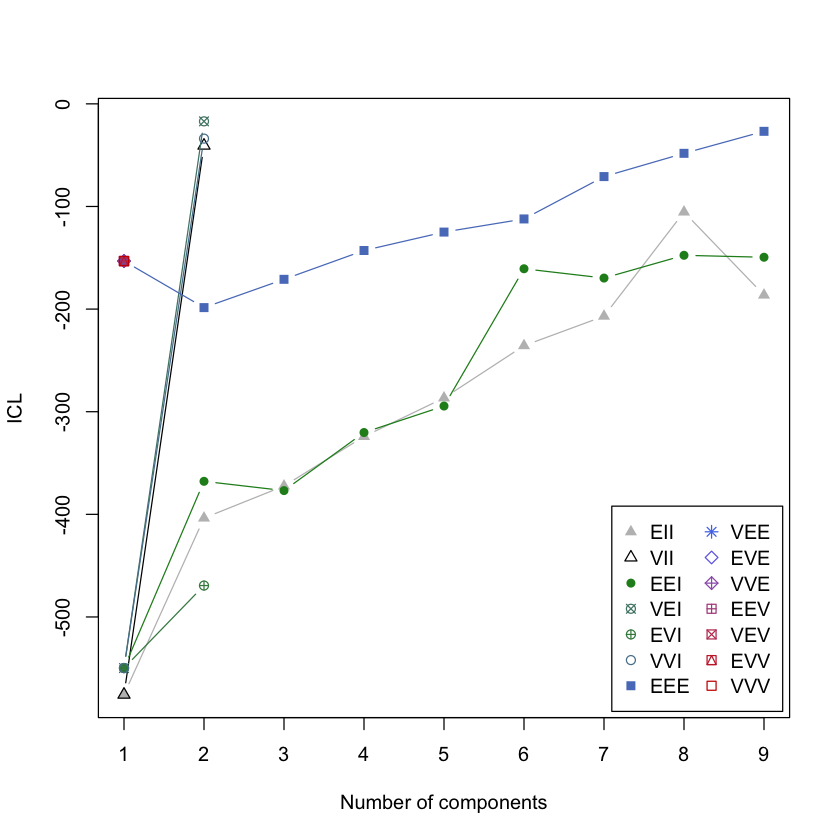

In [22]:
icl_model <- mclustICL(X_sel)
plot(icl_model)

##### 2.3: Matrice de co-association:
Quelles substances se retrouvent toujours ensemble, quel que soit le nombre de classes comportementales qu'on crée?

In [23]:
kmeans_optim <- kmeans(unique(X_sel), centers = 6)

In [24]:
## setup:
K_range <- 4:6
classes <- kmeans_optim$cluster
ordered_classes <- order(classes)
substances <- names(classes)

n <- length(substances)

count_common <- matrix(0, n, n, dimnames = list(substances, substances))

In [25]:
## create co-occ matrix for GMM classif:
for (k in K_range){
    GMM_k <- Mclust(unique(X_sel), G = k)
    classes_k <- GMM_k$classification
    count_common <- count_common + outer(classes_k, classes_k, FUN = "==")*1
}

## get proportion (+ informative):
M_consensus <- count_common / max(count_common)

In [26]:
png("../plots/coassoc_matrix_GMM.png", width = 2000, height = 1600, res = 300)
corrplot::corrplot(M_consensus[ordered_classes, ordered_classes], method = "color", type = "full", col = colorRampPalette(c("red", "yellow", "darkgreen"))(200), tl.col = "black", tl.cex = 0.5, is.corr = FALSE, title = "Matrice de co-occurence des substances")
dev.off()

agg_record_9f7648e9d44f 
                      2

In [27]:
## hierarchical clustering to see subgroups:
d_M <- as.dist(1 - M_consensus)
h_clust <- hclust(d_M, method = "average")
final_labels <- cutree(h_clust, k = 6)

class_labels <- data.frame(substance = names(final_labels), y = final_labels)

png('../plots/h_clust.png', width = 2000, height = 1600, res = 300)
plot(h_clust, cex = 0.7)
dev.off()

agg_record_9f76f9c9ebe 
                     2

In [28]:
## re-ordered matrix:
index_ord <- h_clust$order

par(mar = c(2, 2, 4, 2))
png("../plots/coassoc_matrix_ordered_AGG.png", width = 3400, height = 3300, res = 600)
corrplot::corrplot(M_consensus[index_ord, index_ord], method = "color", type = "full", col = colorRampPalette(c("red", "yellow", "darkgreen"))(200), tl.col = "black", tl.cex = 0.4, cl.cex = 0.6, cl.ratio  = 0.12, is.corr = FALSE, title = "Matrice de co-occurence des substances", mar = c(0, 0, 2, 0))
dev.off()

agg_record_9f7636a2000e 
                      2

In [29]:
table(class_labels$y)


 1  2  3  4  5  6 
 1 13  1 16  1  1 

In [30]:
table(gmm_optim_K7$classification)


 1  2  3  4  5  6 
 1 13  1 16  1  1 

In [31]:
sub_labels <- as.data.frame(gmm_optim_K7$classification)
sub_labels$substance <- rownames(sub_labels)
colnames(sub_labels) <- c("y", "substance")
sub_labels

,y,substance
,<dbl>,<chr>
1-2Dichloroethane,1,1-2Dichloroethane
1-chlorodecane,2,1-chlorodecane
124-Trichlorobenzene,2,124-Trichlorobenzene
4-octylphenol,3,4-octylphenol
A736,2,A736
Acetone,2,Acetone
Acide Acrylique,4,Acide Acrylique
Anthracene,4,Anthracene
Benzene,2,Benzene


In [32]:
table(sub_labels$y)


 1  2  3  4  5  6 
 1 13  1 16  1  1 

In [33]:
write_csv(sub_labels, '../data/classes_df_nomet_behaviour_K7_IGT_AGG.csv')